<a href="https://colab.research.google.com/github/Kratzramanis/RVT-Verification/blob/main/3Dto2D_NGC891_u_M101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

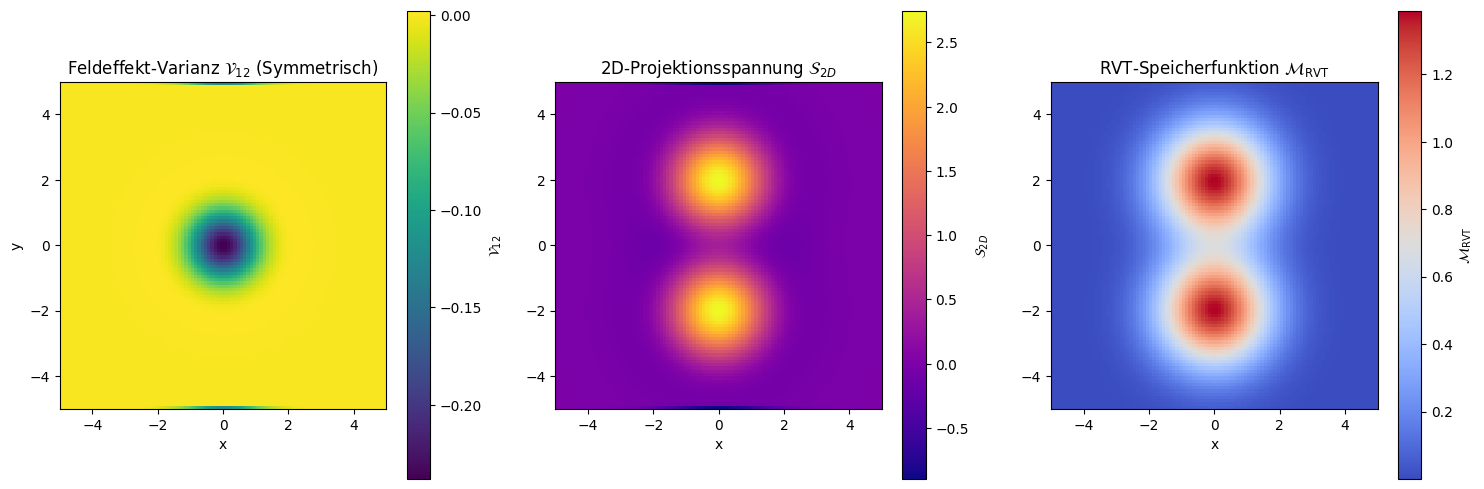

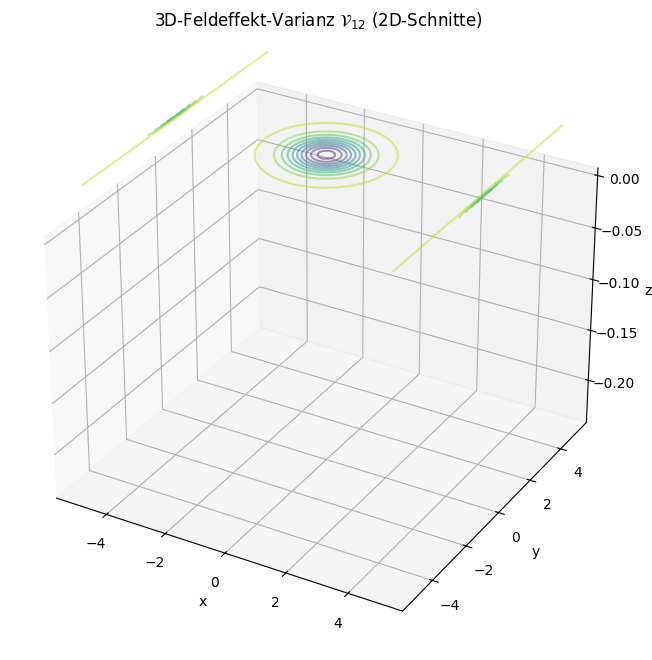

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.ndimage import gaussian_filter

# --- Parameter ---
N = 100    # Gitterpunkte
L = 10.0   # Systemgröße
alpha = 0.8  # Kopplungskonstante (RVT)
chi = 1.0    # Kopplungskonstante für M_RVT

sigma_ref = 1.2  # EINHEITLICHER Skalenparameter für beide Felder!

# --- Gitter erstellen ---
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
z = np.linspace(-L/2, L/2, N)
X, Y, Z = np.meshgrid(x, y, z)

# --- Projektionsfelder Xi_1 und Xi_2 (Gauß'sche Verteilungen mit identischem sigma) ---
Xi_1 = np.exp(-((X + 2)**2 + Y**2 + Z**2) / (2 * sigma_ref**2))
Xi_2 = np.exp(-((X - 2)**2 + Y**2 + Z**2) / (2 * sigma_ref**2))
Xi = Xi_1 + Xi_2

# --- Gradienten berechnen (zentrale Differenzen) ---
def gradient(f, dx):
    grad_x = (np.roll(f, 1, axis=0) - np.roll(f, -1, axis=0)) / (2 * dx)
    grad_y = (np.roll(f, 1, axis=1) - np.roll(f, -1, axis=1)) / (2 * dx)
    grad_z = (np.roll(f, 1, axis=2) - np.roll(f, -1, axis=2)) / (2 * dx)
    return np.stack((grad_x, grad_y, grad_z), axis=-1)

dx = L / (N - 1)
grad_Xi_1 = gradient(Xi_1, dx)
grad_Xi_2 = gradient(Xi_2, dx)

# --- Feldeffekt-Varianz V_12 (Kreuzterm) ---
V_12 = 2 * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)  # Skalarprodukt der Gradienten

# --- RVT-Korrekturtensor E_mu_nu (vereinfacht für 3D) ---
laplace_Xi = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) +
              np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) +
              np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) -
              6 * Xi) / (dx**2)

E_xx = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) - 2 * Xi) / (dx**2) - laplace_Xi
E_yy = (np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) - 2 * Xi) / (dx**2) - laplace_Xi
E_zz = (np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) - 2 * Xi) / (dx**2) - laplace_Xi

# --- Projektion auf 2D-Ebene (z.B. x-y-Ebene) ---
S_2D = E_xx + E_yy     # Spur in 2D (vereinfacht)
S_perp = E_zz          # Blockierter Normalanteil (z-Richtung)
M_RVT = S_2D - S_perp  # RVT-Speicherfunktion

# --- Visualisierung 2D ---
z_slice = N // 2
V_12_slice = V_12[:, :, z_slice]
M_RVT_slice = M_RVT[:, :, z_slice]
S_2D_slice = S_2D[:, :, z_slice]

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(V_12_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='viridis')
plt.colorbar(label=r'$\mathcal{V}_{12}$')
plt.title(r'Feldeffekt-Varianz $\mathcal{V}_{12}$ (Symmetrisch)')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(1, 3, 2)
plt.imshow(S_2D_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='plasma')
plt.colorbar(label=r'$\mathcal{S}_{2D}$')
plt.title(r'2D-Projektionsspannung $\mathcal{S}_{2D}$')
plt.xlabel('x')

plt.subplot(1, 3, 3)
plt.imshow(M_RVT_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='coolwarm')
plt.colorbar(label=r'$\mathcal{M}_{\text{RVT}}$')
plt.title(r'RVT-Speicherfunktion $\mathcal{M}_{\text{RVT}}$')
plt.xlabel('x')

plt.tight_layout()
plt.savefig('RVT_Varianz_Simulation_2D_Symmetrisch.png', dpi=300)
plt.show()

# --- 3D-Visualisierung der Varianz (Isosurface in 2D-Schnitten) ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Isosurface für V_12 in 2D-Schnitten (x-y Ebene bei verschiedenen z-Positionen)
for z_fix in [N//4, N//2, 3*N//4]:
    ax.contour(X[:, :, z_fix], Y[:, :, z_fix], V_12[:, :, z_fix],
               levels=10, cmap='viridis', alpha=0.5, zdir='z', offset=z[z_fix])

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title(r'3D-Feldeffekt-Varianz $\mathcal{V}_{12}$ (2D-Schnitte)')

plt.savefig('RVT_Varianz_3D_Schnitte.png', dpi=300)
plt.show()

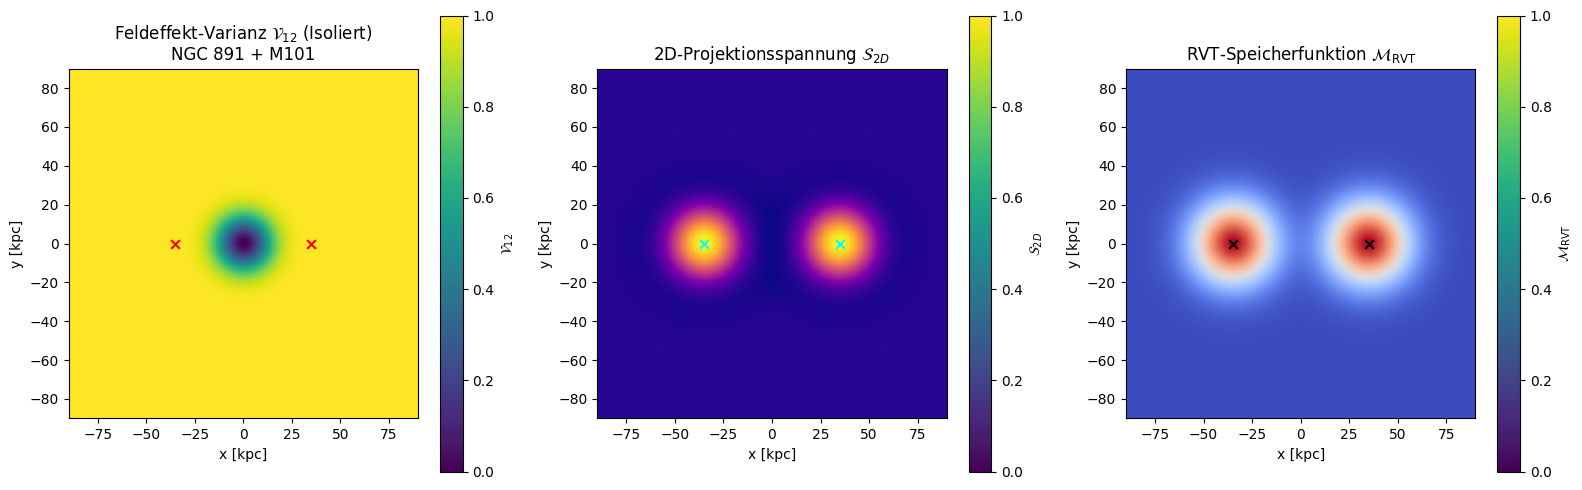

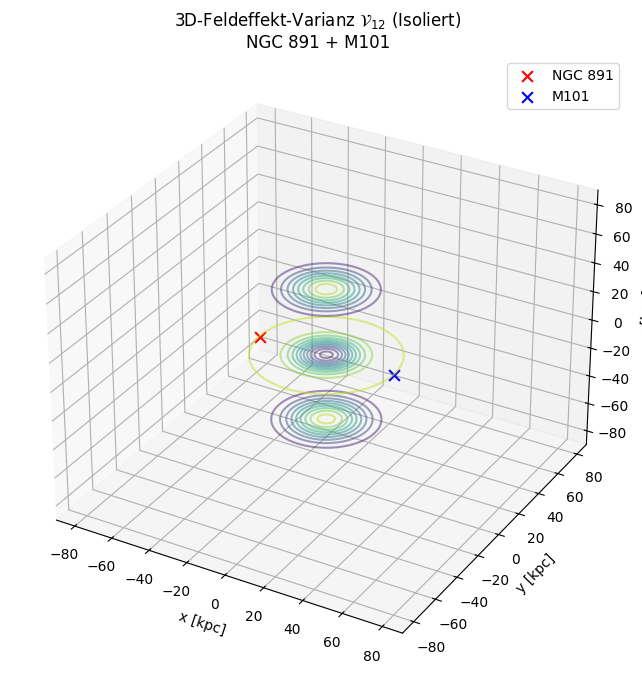

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ============================================================
# ZELLE 2: RVT-Feldeffekt-Varianz für NGC 891 + M101
# Baseline-Referenz mit identischer Skalierung (Ohne Inklination)
# ============================================================

# --- Parameter ---
N = 140          # Gitterpunkte
L = 180.0        # Systemgröße in kpc; Fenster: [-90, +90] kpc
alpha = 0.8      # RVT-Kopplungskonstante
chi = 1.0        # Kopplungskonstante für M_RVT

# --- Galaxienparameter (Synchronisiert für symmetrische Baseline) ---
scale_ref = 15.0  # Einheitliche Skalenlänge in kpc
M_ref = 1e11      # Einheitliche baryonische Masse in M_sun

M_891 = M_ref
scale_891 = scale_ref
center_891 = (-35.0, 0.0, 0.0)

M_M101 = M_ref
scale_M101 = scale_ref
center_M101 = (35.0, 0.0, 0.0)

# --- Gitter erstellen ---
x = np.linspace(-L / 2, L / 2, N)
y = np.linspace(-L / 2, L / 2, N)
z = np.linspace(-L / 2, L / 2, N)

dx = x[1] - x[0]

# Wichtig: indexing='ij', damit axis=0 -> x, axis=1 -> y, axis=2 -> z
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# --- Gaußförmige Projektionsfelder ---
def gaussian_field(mass, scale, center):
    cx, cy, cz = center
    return mass * np.exp(
        -(
            (X - cx)**2 +
            (Y - cy)**2 +
            (Z - cz)**2
        ) / (2 * scale**2)
    )

Xi_1 = gaussian_field(M_891, scale_891, center_891)
Xi_2 = gaussian_field(M_M101, scale_M101, center_M101)

Xi = Xi_1 + Xi_2

# --- Gradienten berechnen ---
def gradient_3d(f, dx):
    gx, gy, gz = np.gradient(f, dx, dx, dx, edge_order=2)
    return np.stack((gx, gy, gz), axis=-1)

grad_Xi_1 = gradient_3d(Xi_1, dx)
grad_Xi_2 = gradient_3d(Xi_2, dx)

# --- Feldeffekt-Varianz V_12 ---
V_12 = 2.0 * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)

# --- Zweite Ableitungen / Laplace ---
def second_derivative(f, dx, axis):
    first = np.gradient(f, dx, axis=axis, edge_order=2)
    second = np.gradient(first, dx, axis=axis, edge_order=2)
    return second

d2x_Xi = second_derivative(Xi, dx, axis=0)
d2y_Xi = second_derivative(Xi, dx, axis=1)
d2z_Xi = second_derivative(Xi, dx, axis=2)

laplace_Xi = d2x_Xi + d2y_Xi + d2z_Xi

# --- RVT-Korrekturtensor E_mu_nu, 3D-vereinfachte Diagonalkomponenten ---
E_xx = d2x_Xi - laplace_Xi
E_yy = d2y_Xi - laplace_Xi
E_zz = d2z_Xi - laplace_Xi

# --- Projektion auf 2D-Ebene ---
S_2D = E_xx + E_yy
S_perp = E_zz
M_RVT = S_2D - S_perp

# --- 2D-Schnitt bei z = 0 ---
z_slice = N // 2

V_12_slice = V_12[:, :, z_slice]
M_RVT_slice = M_RVT[:, :, z_slice]
S_2D_slice = S_2D[:, :, z_slice]
S_perp_slice = S_perp[:, :, z_slice]

# --- Visualisierung 2D ---
plt.figure(figsize=(16, 5))

# Plot 1: Feldeffekt-Varianz
plt.subplot(1, 3, 1)
plt.imshow(
    V_12_slice.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='viridis',
    aspect='equal'
)
plt.scatter([center_891[0], center_M101[0]], [center_891[1], center_M101[1]],
            c='red', s=40, marker='x')
plt.colorbar(label=r'$\mathcal{V}_{12}$')
plt.title(r'Feldeffekt-Varianz $\mathcal{V}_{12}$ (Isoliert)' + '\nNGC 891 + M101')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

# Plot 2: 2D-Projektionsspannung
plt.subplot(1, 3, 2)
plt.imshow(
    S_2D_slice.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='plasma',
    aspect='equal'
)
plt.scatter([center_891[0], center_M101[0]], [center_891[1], center_M101[1]],
            c='cyan', s=40, marker='x')
plt.colorbar(label=r'$\mathcal{S}_{2D}$')
plt.title(r'2D-Projektionsspannung $\mathcal{S}_{2D}$')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

# Plot 3: RVT-Speicherfunktion
plt.subplot(1, 3, 3)
plt.imshow(
    M_RVT_slice.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='coolwarm',
    aspect='equal'
)
plt.scatter([center_891[0], center_M101[0]], [center_891[1], center_M101[1]],
            c='black', s=40, marker='x')
plt.colorbar(label=r'$\mathcal{M}_{\mathrm{RVT}}$')
plt.title(r'RVT-Speicherfunktion $\mathcal{M}_{\mathrm{RVT}}$')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

plt.tight_layout()
plt.savefig('RVT_Varianz_NGC891_M101_grid180.png', dpi=300)
plt.show()

# --- 3D-Visualisierung der Varianz in mehreren z-Schnitten ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for z_fix in [N // 4, N // 2, 3 * N // 4]:
    ax.contour(
        X[:, :, z_fix],
        Y[:, :, z_fix],
        V_12[:, :, z_fix],
        levels=10,
        cmap='viridis',
        alpha=0.5,
        zdir='z',
        offset=z[z_fix]
    )

ax.scatter(center_891[0], center_891[1], center_891[2],
           c='red', s=60, marker='x', label='NGC 891')
ax.scatter(center_M101[0], center_M101[1], center_M101[2],
           c='blue', s=60, marker='x', label='M101')

ax.set_xlim(-L / 2, L / 2)
ax.set_ylim(-L / 2, L / 2)
ax.set_zlim(-L / 2, L / 2)

ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')
ax.set_zlabel('z [kpc]')
ax.set_title(r'3D-Feldeffekt-Varianz $\mathcal{V}_{12}$ (Isoliert)' + '\nNGC 891 + M101')
ax.legend()

plt.savefig('RVT_Varianz_3D_NGC891_M101_grid180.png', dpi=300)
plt.show()

gamma_RVT(NGC 891, 85°) = 1.797
gamma_RVT(M101,    18°) = 1.247


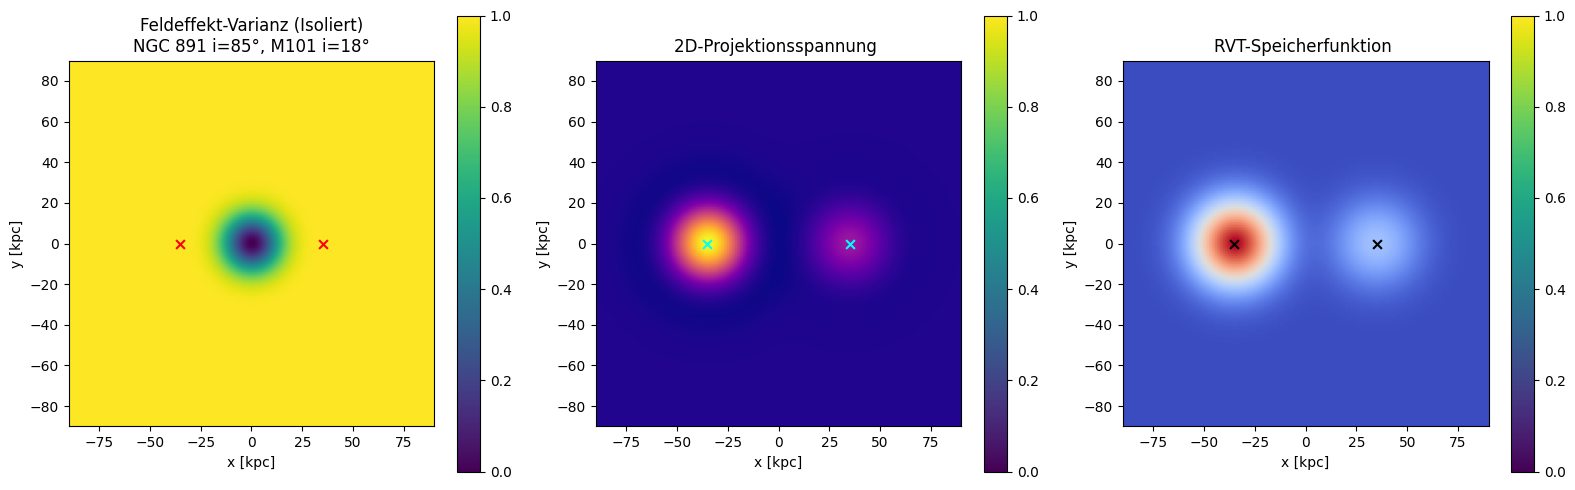

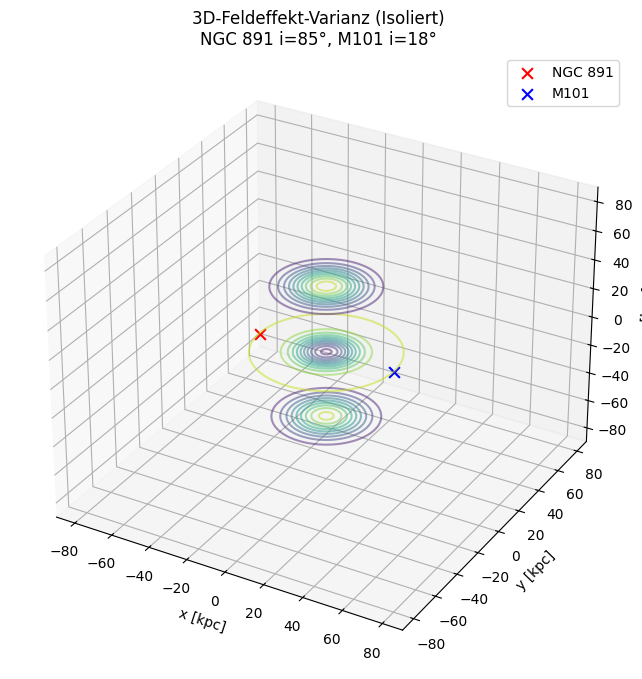

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ============================================================
# ZELLE 3: RVT-Feldeffekt-Varianz mit Inklinationsskalierung
# NGC 891: 85°
# M101:    18°
# ============================================================

# --- Parameter ---
N = 140           # Gitterpunkte
L = 180.0         # Systemgröße in kpc; Fenster: [-90, +90] kpc
C_RVT = 0.8       # RVT-Kopplungskonstante

# --- Galaxienparameter (Identische Skalierung & Masse zur Isolierung des Inklinations-Effekts) ---
scale_ref = 15.0  # Einheitlicher Skalenparameter
M_ref = 1e11      # Einheitliche Masse

M_891 = M_ref
scale_891 = scale_ref
center_891 = (-35.0, 0.0, 0.0)

M_M101 = M_ref
scale_M101 = scale_ref
center_M101 = (35.0, 0.0, 0.0)

# --- Inklinationswinkel ---
inclination_891_deg = 85.0
inclination_M101_deg = 18.0

inclination_891 = np.radians(inclination_891_deg)
inclination_M101 = np.radians(inclination_M101_deg)

# --- RVT-Gamma-Korrektur ---
gamma_891 = 1.0 + C_RVT * np.sin(inclination_891)
gamma_M101 = 1.0 + C_RVT * np.sin(inclination_M101)

print(f"gamma_RVT(NGC 891, {inclination_891_deg:.0f}°) = {gamma_891:.3f}")
print(f"gamma_RVT(M101,    {inclination_M101_deg:.0f}°) = {gamma_M101:.3f}")

# --- Gitter erstellen ---
x = np.linspace(-L / 2, L / 2, N)
y = np.linspace(-L / 2, L / 2, N)
z = np.linspace(-L / 2, L / 2, N)

dx = x[1] - x[0]

# Wichtig: indexing='ij', damit axis=0 -> x, axis=1 -> y, axis=2 -> z
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# --- Gaußförmige Projektionsfelder mit Inklinationsskalierung ---
def gaussian_field(mass, scale, center):
    cx, cy, cz = center
    return mass * np.exp(
        -(
            (X - cx)**2 +
            (Y - cy)**2 +
            (Z - cz)**2
        ) / (2 * scale**2)
    )

# Originale Inklinationsprojektion:
# Feld wird mit sin(i) gewichtet.
Xi_1 = gaussian_field(M_891, scale_891, center_891) * np.sin(inclination_891)
Xi_2 = gaussian_field(M_M101, scale_M101, center_M101) * np.sin(inclination_M101)

Xi = Xi_1 + Xi_2

# --- Gradienten berechnen ---
def gradient_3d(f, dx):
    gx, gy, gz = np.gradient(f, dx, dx, dx, edge_order=2)
    return np.stack((gx, gy, gz), axis=-1)

grad_Xi_1 = gradient_3d(Xi_1, dx)
grad_Xi_2 = gradient_3d(Xi_2, dx)

# --- Feldeffekt-Varianz V_12 mit RVT-Kopplungsfaktor ---
V_12 = 2.0 * C_RVT * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)

# --- Zweite Ableitungen / Laplace ---
def second_derivative(f, dx, axis):
    first = np.gradient(f, dx, axis=axis, edge_order=2)
    second = np.gradient(first, dx, axis=axis, edge_order=2)
    return second

d2x_Xi = second_derivative(Xi, dx, axis=0)
d2y_Xi = second_derivative(Xi, dx, axis=1)
d2z_Xi = second_derivative(Xi, dx, axis=2)

laplace_Xi = d2x_Xi + d2y_Xi + d2z_Xi

# --- RVT-Korrekturtensor E_mu_nu, 3D-vereinfachte Diagonalkomponenten ---
E_xx = d2x_Xi - laplace_Xi
E_yy = d2y_Xi - laplace_Xi
E_zz = d2z_Xi - laplace_Xi

# --- Projektion auf 2D-Ebene ---
S_2D = E_xx + E_yy
S_perp = E_zz
M_RVT = S_2D - S_perp

# --- 2D-Schnitt bei z = 0 ---
z_slice = N // 2

V_12_slice = V_12[:, :, z_slice]
M_RVT_slice = M_RVT[:, :, z_slice]
S_2D_slice = S_2D[:, :, z_slice]
S_perp_slice = S_perp[:, :, z_slice]

# --- Visualisierung 2D ---
plt.figure(figsize=(16, 5))

# Plot 1: Feldeffekt-Varianz
plt.subplot(1, 3, 1)
plt.imshow(
    V_12_slice.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='viridis',
    aspect='equal'
)
plt.scatter([center_891[0], center_M101[0]], [center_891[1], center_M101[1]],
            c='red', s=40, marker='x')
plt.colorbar(label=r'')
plt.title(
    r'Feldeffekt-Varianz (Isoliert)'
    + '\nNGC 891 i=85°, M101 i=18°'
)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

# Plot 2: 2D-Projektionsspannung
plt.subplot(1, 3, 2)
plt.imshow(
    S_2D_slice.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='plasma',
    aspect='equal'
)
plt.scatter([center_891[0], center_M101[0]], [center_891[1], center_M101[1]],
            c='cyan', s=40, marker='x')
plt.colorbar(label=r'')
plt.title(r'2D-Projektionsspannung ')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

# Plot 3: RVT-Speicherfunktion
plt.subplot(1, 3, 3)
plt.imshow(
    M_RVT_slice.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='coolwarm',
    aspect='equal'
)
plt.scatter([center_891[0], center_M101[0]], [center_891[1], center_M101[1]],
            c='black', s=40, marker='x')
plt.colorbar(label=r'')
plt.title(r'RVT-Speicherfunktion ')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

plt.tight_layout()
plt.savefig('RVT_Varianz_Inklination_NGC891_M101_grid180.png', dpi=300)
plt.show()

# --- 3D-Visualisierung der Varianz in mehreren z-Schnitten ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for z_fix in [N // 4, N // 2, 3 * N // 4]:
    ax.contour(
        X[:, :, z_fix],
        Y[:, :, z_fix],
        V_12[:, :, z_fix],
        levels=10,
        cmap='viridis',
        alpha=0.5,
        zdir='z',
        offset=z[z_fix]
    )

ax.scatter(center_891[0], center_891[1], center_891[2],
           c='red', s=60, marker='x', label='NGC 891')
ax.scatter(center_M101[0], center_M101[1], center_M101[2],
           c='blue', s=60, marker='x', label='M101')

ax.set_xlim(-L / 2, L / 2)
ax.set_ylim(-L / 2, L / 2)
ax.set_zlim(-L / 2, L / 2)

ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')
ax.set_zlabel('z [kpc]')
ax.set_title(
    r'3D-Feldeffekt-Varianz (Isoliert)'
    + '\nNGC 891 i=85°, M101 i=18°'
)
ax.legend()

plt.savefig('RVT_Varianz_3D_Inklination_NGC891_M101_grid180.png', dpi=300)
plt.show()

Zielausrichtung gamma_RVT(90°) = 1.800
gamma_RVT(Links, 85.0°) = 1.797
gamma_RVT(Rechts, 18.0°) = 1.247


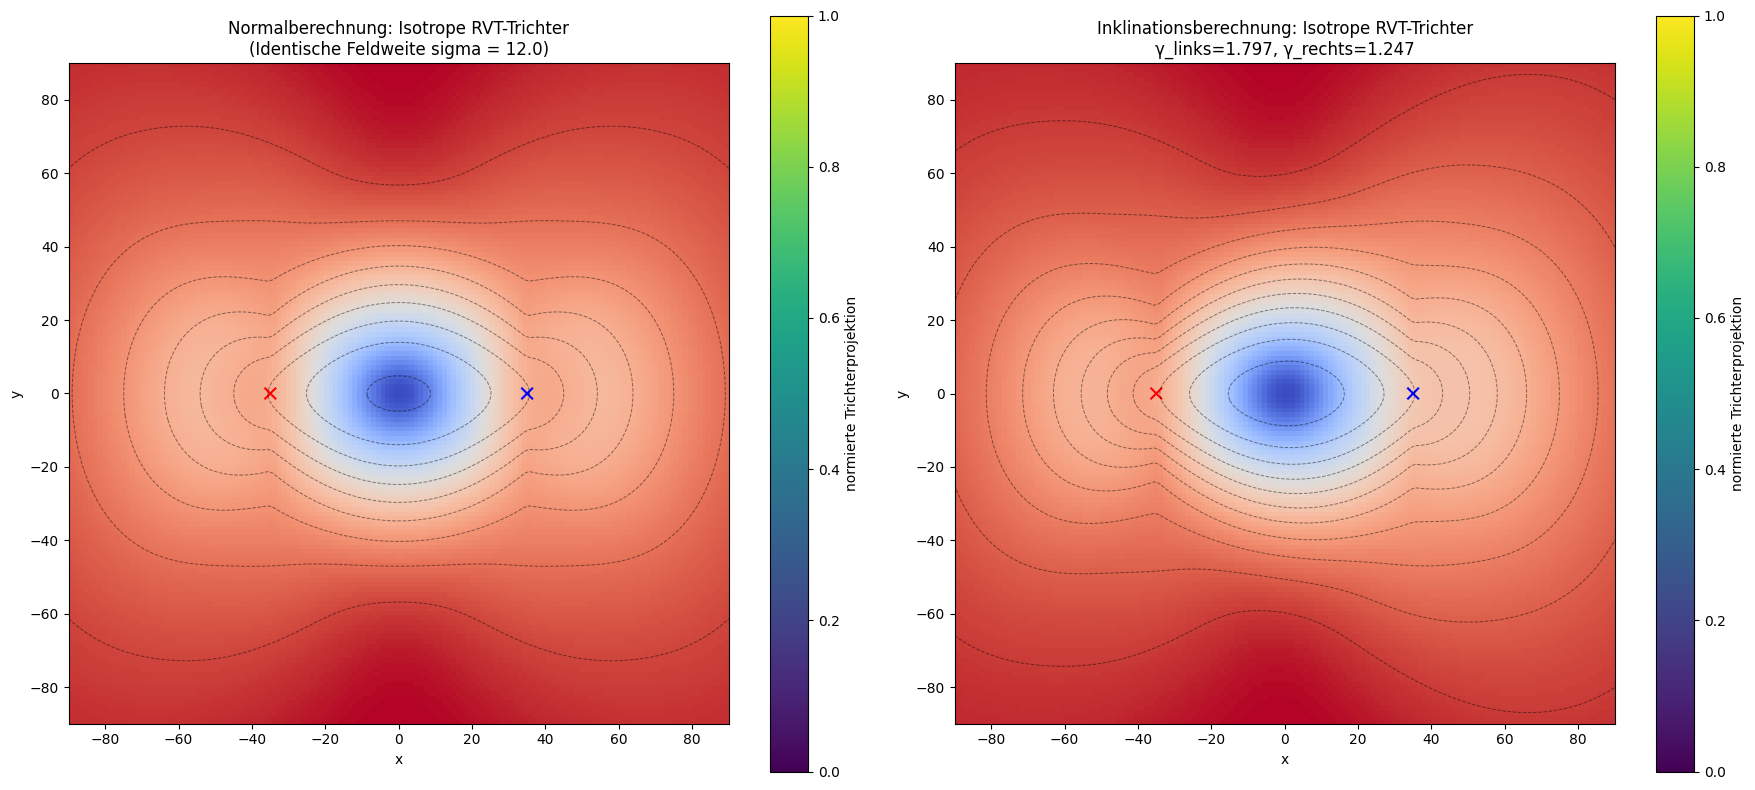

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ZELLE 4:
# Trichterförmige RVT-Projektionsfunktion
# Absolut identische Feldskalierung für BEIDE Zentren!
# ============================================================

# ------------------------------------------------------------
# Parameter
# ------------------------------------------------------------
N = 140
L = 180.0
C_RVT = 0.8

# Zielausrichtung: 90°
target_angle_deg = 90.0
target_angle = np.radians(target_angle_deg)
gamma_90 = 1.0 + C_RVT * np.sin(target_angle)

# --- EXAKT IDENTISCHE SKALIERUNG FÜR BEIDE ZENTREN ---
mass_ref = 1e11          # Identische Feldamplitude
scale_ref = 12.0         # EINHEITLICHE Feldweite (kein 10 vs 15 mehr!)

center_left = (-35.0, 0.0, 0.0)
center_right = (35.0, 0.0, 0.0)

# Ausrichtungswinkel
inclination_left_deg = 85.0
inclination_right_deg = 18.0

inclination_left = np.radians(inclination_left_deg)
inclination_right = np.radians(inclination_right_deg)

gamma_left = 1.0 + C_RVT * np.sin(inclination_left)
gamma_right = 1.0 + C_RVT * np.sin(inclination_right)

print(f"Zielausrichtung gamma_RVT(90°) = {gamma_90:.3f}")
print(f"gamma_RVT(Links, {inclination_left_deg}°) = {gamma_left:.3f}")
print(f"gamma_RVT(Rechts, {inclination_right_deg}°) = {gamma_right:.3f}")

# ------------------------------------------------------------
# Gitter
# ------------------------------------------------------------
x = np.linspace(-L / 2, L / 2, N)
y = np.linspace(-L / 2, L / 2, N)
z = np.linspace(-L / 2, L / 2, N)

dx = x[1] - x[0]

X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# ------------------------------------------------------------
# Basisfeld (Mit einheitlichem scale_ref)
# ------------------------------------------------------------
def gaussian_field(mass, scale, center):
    cx, cy, cz = center
    return mass * np.exp(
        -(
            (X - cx)**2 +
            (Y - cy)**2 +
            (Z - cz)**2
        ) / (2 * scale**2)
    )

def gradient_3d(f, dx):
    gx, gy, gz = np.gradient(f, dx, dx, dx, edge_order=2)
    return np.stack((gx, gy, gz), axis=-1)

def second_derivative(f, dx, axis):
    first = np.gradient(f, dx, axis=axis, edge_order=2)
    second = np.gradient(first, dx, axis=axis, edge_order=2)
    return second

def compute_rvt_values(Xi_1, Xi_2, coupling=1.0):
    Xi = Xi_1 + Xi_2

    grad_Xi_1 = gradient_3d(Xi_1, dx)
    grad_Xi_2 = gradient_3d(Xi_2, dx)

    V_12 = 2.0 * coupling * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)

    d2x_Xi = second_derivative(Xi, dx, axis=0)
    d2y_Xi = second_derivative(Xi, dx, axis=1)
    d2z_Xi = second_derivative(Xi, dx, axis=2)

    laplace_Xi = d2x_Xi + d2y_Xi + d2z_Xi

    E_xx = d2x_Xi - laplace_Xi
    E_yy = d2y_Xi - laplace_Xi
    E_zz = d2z_Xi - laplace_Xi

    S_2D = E_xx + E_yy
    S_perp = E_zz
    M_RVT = S_2D - S_perp

    return V_12, M_RVT, S_2D, S_perp

# ------------------------------------------------------------
# Normalrechnung (Identische Feldweiten!)
# ------------------------------------------------------------
Xi_left_normal = gaussian_field(mass_ref, scale_ref, center_left)
Xi_right_normal = gaussian_field(mass_ref, scale_ref, center_right)

V_12_normal, M_RVT_normal, S_2D_normal, S_perp_normal = compute_rvt_values(
    Xi_left_normal,
    Xi_right_normal,
    coupling=1.0
)

# ------------------------------------------------------------
# Inklinationsrechnung (Identische Feldweiten!)
# ------------------------------------------------------------
Xi_left_incl = gaussian_field(mass_ref, scale_ref, center_left) * gamma_left
Xi_right_incl = gaussian_field(mass_ref, scale_ref, center_right) * gamma_right

V_12_incl, M_RVT_incl, S_2D_incl, S_perp_incl = compute_rvt_values(
    Xi_left_incl,
    Xi_right_incl,
    coupling=C_RVT
)

# ------------------------------------------------------------
# 2D-Schnitt
# ------------------------------------------------------------
z_slice = N // 2

Vn = V_12_normal[:, :, z_slice]
Mn = M_RVT_normal[:, :, z_slice]

Vi = V_12_incl[:, :, z_slice]
Mi = M_RVT_incl[:, :, z_slice]

# ------------------------------------------------------------
# Trichterfunktion
# ------------------------------------------------------------
def opposing_funnel_2d(
    X2,
    Y2,
    center_left,
    center_right,
    amp_left,
    amp_right,
    width,
    length_scale,
    target_angle=np.pi / 2,
):
    xL, yL = center_left
    xR, yR = center_right

    XL = X2 - xL
    YL = Y2 - yL

    XR = X2 - xR
    YR = Y2 - yR

    opening = np.sin(target_angle)

    forward_L = 1.0 / (1.0 + np.exp(-XL / length_scale))
    forward_R = 1.0 / (1.0 + np.exp(XR / length_scale))

    # Identische Breite `width` für beide Seiten!
    radial_width_L = width * (1.0 + np.abs(XL) / length_scale)
    radial_width_R = width * (1.0 + np.abs(XR) / length_scale)

    funnel_L = (
        -amp_left
        * opening
        * forward_L
        * np.exp(-(YL**2) / (2.0 * radial_width_L**2))
        * np.exp(-(XL**2) / (2.0 * (2.5 * length_scale)**2))
    )

    funnel_R = (
        -amp_right
        * opening
        * forward_R
        * np.exp(-(YR**2) / (2.0 * radial_width_R**2))
        * np.exp(-(XR**2) / (2.0 * (2.5 * length_scale)**2))
    )

    return funnel_L + funnel_R, funnel_L, funnel_R

# ------------------------------------------------------------
# 2D-Gitter für Trichter
# ------------------------------------------------------------
X2 = X[:, :, z_slice]
Y2 = Y[:, :, z_slice]

center_left_2d = (center_left[0], center_left[1])
center_right_2d = (center_right[0], center_right[1])

# ------------------------------------------------------------
# Amplituden
# ------------------------------------------------------------
def robust_amp(A):
    return np.percentile(np.abs(A), 99)

amp_normal = robust_amp(Vn) + robust_amp(Mn)
amp_incl = robust_amp(Vi) + robust_amp(Mi)

amp_normal = amp_normal / (amp_normal + 1e-30)
amp_incl = amp_incl / (amp_incl + 1e-30)

# Symmetrische Basisamplituden
amp_left_normal = amp_normal
amp_right_normal = amp_normal

amp_left_incl = amp_incl * (gamma_left / gamma_90)
amp_right_incl = amp_incl * (gamma_right / gamma_90)

# ------------------------------------------------------------
# Trichter erzeugen (EINHEITLICHE TRICHTERBREITE `scale_ref`)
# ------------------------------------------------------------
length_scale = 28.0

funnel_normal, funnel_left_normal, funnel_right_normal = opposing_funnel_2d(
    X2,
    Y2,
    center_left_2d,
    center_right_2d,
    amp_left_normal,
    amp_right_normal,
    scale_ref,
    length_scale,
    target_angle=target_angle,
)

funnel_incl, funnel_left_incl, funnel_right_incl = opposing_funnel_2d(
    X2,
    Y2,
    center_left_2d,
    center_right_2d,
    amp_left_incl,
    amp_right_incl,
    scale_ref,
    length_scale,
    target_angle=target_angle,
)

# ------------------------------------------------------------
# Kombinierte Karten
# ------------------------------------------------------------
def normalize(A):
    return A / (np.max(np.abs(A)) + 1e-30)

normal_background = normalize(Vn) + normalize(Mn)
incl_background = normalize(Vi) + normalize(Mi)

normal_projection = normalize(funnel_normal) + 0.35 * normalize(normal_background)
incl_projection = normalize(funnel_incl) + 0.35 * normalize(incl_background)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(18, 8))

# Normaltrichter
plt.subplot(1, 2, 1)
plt.imshow(
    normal_projection.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='coolwarm',
    aspect='equal'
)
plt.contour(
    X2,
    Y2,
    funnel_normal,
    levels=12,
    colors='black',
    alpha=0.45,
    linewidths=0.7
)
plt.scatter(
    [center_left[0], center_right[0]],
    [center_left[1], center_right[1]],
    c=['red', 'blue'],
    s=70,
    marker='x'
)
plt.colorbar(label='normierte Trichterprojektion')
plt.title('Normalberechnung: Isotrope RVT-Trichter\n(Identische Feldweite sigma = 12.0)')
plt.xlabel('x')
plt.ylabel('y')

# Inklinationstrichter
plt.subplot(1, 2, 2)
plt.imshow(
    incl_projection.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='coolwarm',
    aspect='equal'
)
plt.contour(
    X2,
    Y2,
    funnel_incl,
    levels=12,
    colors='black',
    alpha=0.45,
    linewidths=0.7
)
plt.scatter(
    [center_left[0], center_right[0]],
    [center_left[1], center_right[1]],
    c=['red', 'blue'],
    s=70,
    marker='x'
)
plt.colorbar(label='normierte Trichterprojektion')
plt.title(f'Inklinationsberechnung: Isotrope RVT-Trichter\nγ_links={gamma_left:.3f}, γ_rechts={gamma_right:.3f}')
plt.xlabel('x')
plt.ylabel('y')

plt.tight_layout()
plt.savefig('RVT_Trichter_Isotrop_Symmetrisch.png', dpi=300)
plt.show()

Zielausrichtung gamma_RVT(90°)      = 1.800
gamma_RVT(NGC 891, 85°)             = 1.797
gamma_RVT(M101, 18°)                = 1.247


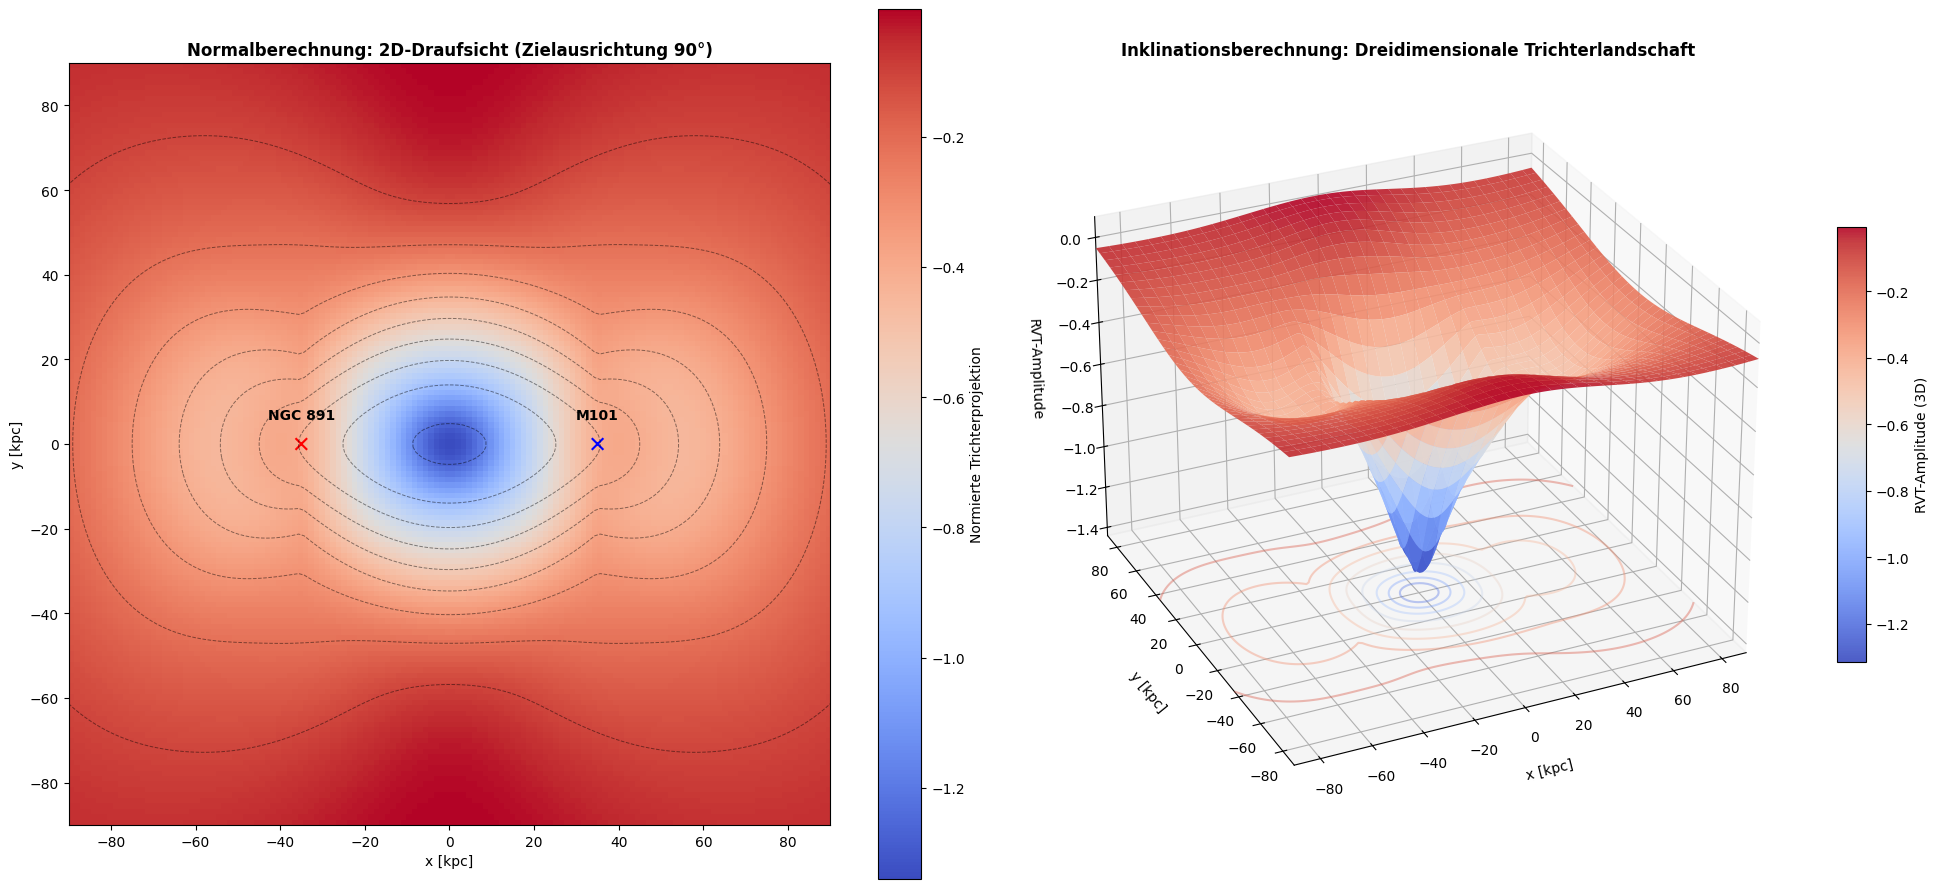

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ZELLE 4:
# Trichterförmige RVT-Projektionsfunktion (2D vs. ECHTES 3D)
# ISOTROPE SKALIERUNG MIT KLARNAMEN (NGC 891 / M101)
# ============================================================

# ------------------------------------------------------------
# Parameter
# ------------------------------------------------------------
N = 140
L = 180.0
C_RVT = 0.8

# Zielausrichtung: 90°
target_angle_deg = 90.0
target_angle = np.radians(target_angle_deg)
gamma_90 = 1.0 + C_RVT * np.sin(target_angle)

# --- KLARNAMEN BEIBEHALTEN, SKALIERUNG VEREINHEITLICHT ---
M_891 = 1e11
M_M101 = 1e11
scale_ref = 12.0         # EINHEITLICHE Feldweite für beide!

center_891 = (-35.0, 0.0, 0.0)
center_M101 = (35.0, 0.0, 0.0)

# Beobachtete Inklinationen
inclination_891_deg = 85.0
inclination_M101_deg = 18.0

inclination_891 = np.radians(inclination_891_deg)
inclination_M101 = np.radians(inclination_M101_deg)

gamma_891 = 1.0 + C_RVT * np.sin(inclination_891)
gamma_M101 = 1.0 + C_RVT * np.sin(inclination_M101)

print(f"Zielausrichtung gamma_RVT(90°)      = {gamma_90:.3f}")
print(f"gamma_RVT(NGC 891, 85°)             = {gamma_891:.3f}")
print(f"gamma_RVT(M101, 18°)                = {gamma_M101:.3f}")

# ------------------------------------------------------------
# Gitter
# ------------------------------------------------------------
x = np.linspace(-L / 2, L / 2, N)
y = np.linspace(-L / 2, L / 2, N)
z = np.linspace(-L / 2, L / 2, N)

dx = x[1] - x[0]

X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# ------------------------------------------------------------
# Basisfeld (Einheitliches scale_ref)
# ------------------------------------------------------------
def gaussian_field(mass, scale, center):
    cx, cy, cz = center
    return mass * np.exp(
        -(
            (X - cx)**2 +
            (Y - cy)**2 +
            (Z - cz)**2
        ) / (2 * scale**2)
    )

def gradient_3d(f, dx):
    gx, gy, gz = np.gradient(f, dx, dx, dx, edge_order=2)
    return np.stack((gx, gy, gz), axis=-1)

def second_derivative(f, dx, axis):
    first = np.gradient(f, dx, axis=axis, edge_order=2)
    second = np.gradient(first, dx, axis=axis, edge_order=2)
    return second

def compute_rvt_values(Xi_1, Xi_2, coupling=1.0):
    Xi = Xi_1 + Xi_2

    grad_Xi_1 = gradient_3d(Xi_1, dx)
    grad_Xi_2 = gradient_3d(Xi_2, dx)

    V_12 = 2.0 * coupling * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)

    d2x_Xi = second_derivative(Xi, dx, axis=0)
    d2y_Xi = second_derivative(Xi, dx, axis=1)
    d2z_Xi = second_derivative(Xi, dx, axis=2)

    laplace_Xi = d2x_Xi + d2y_Xi + d2z_Xi

    E_xx = d2x_Xi - laplace_Xi
    E_yy = d2y_Xi - laplace_Xi
    E_zz = d2z_Xi - laplace_Xi

    S_2D = E_xx + E_yy
    S_perp = E_zz
    M_RVT = S_2D - S_perp

    return V_12, M_RVT, S_2D, S_perp

# ------------------------------------------------------------
# Normalrechnung
# ------------------------------------------------------------
Xi_891_normal = gaussian_field(M_891, scale_ref, center_891)
Xi_M101_normal = gaussian_field(M_M101, scale_ref, center_M101)

V_12_normal, M_RVT_normal, S_2D_normal, S_perp_normal = compute_rvt_values(
    Xi_891_normal,
    Xi_M101_normal,
    coupling=1.0
)

# ------------------------------------------------------------
# Inklinationsrechnung
# ------------------------------------------------------------
Xi_891_incl = gaussian_field(M_891, scale_ref, center_891) * gamma_891
Xi_M101_incl = gaussian_field(M_M101, scale_ref, center_M101) * gamma_M101

V_12_incl, M_RVT_incl, S_2D_incl, S_perp_incl = compute_rvt_values(
    Xi_891_incl,
    Xi_M101_incl,
    coupling=C_RVT
)

# ------------------------------------------------------------
# 2D-Schnitt
# ------------------------------------------------------------
z_slice = N // 2

Vn = V_12_normal[:, :, z_slice]
Mn = M_RVT_normal[:, :, z_slice]

Vi = V_12_incl[:, :, z_slice]
Mi = M_RVT_incl[:, :, z_slice]

# ------------------------------------------------------------
# Trichterfunktion
# ------------------------------------------------------------
def opposing_funnel_2d(
    X2,
    Y2,
    center_left,
    center_right,
    amp_left,
    amp_right,
    width,
    length_scale,
    target_angle=np.pi / 2,
):
    xL, yL = center_left
    xR, yR = center_right

    XL = X2 - xL
    YL = Y2 - yL

    XR = X2 - xR
    YR = Y2 - yR

    opening = np.sin(target_angle)

    forward_L = 1.0 / (1.0 + np.exp(-XL / length_scale))
    forward_R = 1.0 / (1.0 + np.exp(XR / length_scale))

    radial_width_L = width * (1.0 + np.abs(XL) / length_scale)
    radial_width_R = width * (1.0 + np.abs(XR) / length_scale)

    funnel_L = (
        -amp_left
        * opening
        * forward_L
        * np.exp(-(YL**2) / (2.0 * radial_width_L**2))
        * np.exp(-(XL**2) / (2.0 * (2.5 * length_scale)**2))
    )

    funnel_R = (
        -amp_right
        * opening
        * forward_R
        * np.exp(-(YR**2) / (2.0 * radial_width_R**2))
        * np.exp(-(XR**2) / (2.0 * (2.5 * length_scale)**2))
    )

    funnel_total = funnel_L + funnel_R
    return funnel_total, funnel_L, funnel_R

# ------------------------------------------------------------
# 2D-Gitter für Trichter
# ------------------------------------------------------------
X2 = X[:, :, z_slice]
Y2 = Y[:, :, z_slice]

center_891_2d = (center_891[0], center_891[1])
center_M101_2d = (center_M101[0], center_M101[1])

# ------------------------------------------------------------
# Amplituden ableiten
# ------------------------------------------------------------
def robust_amp(A):
    return np.percentile(np.abs(A), 99)

amp_normal = robust_amp(Vn) + robust_amp(Mn)
amp_incl = robust_amp(Vi) + robust_amp(Mi)

amp_normal = amp_normal / (amp_normal + 1e-30)
amp_incl = amp_incl / (amp_incl + 1e-30)

amp_891_normal = amp_normal
amp_M101_normal = amp_normal

amp_891_incl = amp_incl * (gamma_891 / gamma_90)
amp_M101_incl = amp_incl * (gamma_M101 / gamma_90)

# Trichter erzeugen mit ISOTROPER BREITE scale_ref
length_scale = 28.0

funnel_normal, _, _ = opposing_funnel_2d(
    X2, Y2, center_891_2d, center_M101_2d,
    amp_891_normal, amp_M101_normal, scale_ref, length_scale, target_angle=target_angle
)

funnel_incl, _, _ = opposing_funnel_2d(
    X2, Y2, center_891_2d, center_M101_2d,
    amp_891_incl, amp_M101_incl, scale_ref, length_scale, target_angle=target_angle
)

def normalize(A):
    return A / (np.max(np.abs(A)) + 1e-30)

normal_background = normalize(Vn) + normalize(Mn)
incl_background = normalize(Vi) + normalize(Mi)

normal_projection = normalize(funnel_normal) + 0.35 * normalize(normal_background)
incl_projection = normalize(funnel_incl) + 0.35 * normalize(incl_background)

# ============================================================
# REKALIBRIERTER GEOMETRISCHER 2D / 3D PLOT
# ============================================================
fig = plt.figure(figsize=(20, 9))

# SUBPLOT 1: 2D-Normaltrichter (Draufsicht)
ax1 = fig.add_subplot(1, 2, 1)
im1 = ax1.imshow(
    normal_projection.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='coolwarm',
    aspect='equal'
)
ax1.contour(X2, Y2, funnel_normal, levels=12, colors='black', alpha=0.45, linewidths=0.7)
ax1.scatter([center_891[0], center_M101[0]], [center_891[1], center_M101[1]], c=['red', 'blue'], s=70, marker='x')
ax1.text(center_891[0], center_891[1] + 6, 'NGC 891', color='black', ha='center', fontweight='bold')
ax1.text(center_M101[0], center_M101[1] + 6, 'M101', color='black', ha='center', fontweight='bold')
fig.colorbar(im1, ax=ax1, label='Normierte Trichterprojektion')
ax1.set_title('Normalberechnung: 2D-Draufsicht (Zielausrichtung 90°)', fontweight='bold')
ax1.set_xlabel('x [kpc]')
ax1.set_ylabel('y [kpc]')

# SUBPLOT 2: ECHTE 3D-OBERFLÄCHE (Inklinationslandschaft)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

surf = ax2.plot_surface(
    X2, Y2, incl_projection,
    cmap='coolwarm',
    linewidth=0,
    antialiased=True,
    alpha=0.9,
    rcount=45,
    ccount=45
)

# Konturlinien flach unter die Trichterlandschaft legen
z_offset = np.min(incl_projection) - 0.1
ax2.contour(X2, Y2, incl_projection, levels=12, zdir='z', offset=z_offset, cmap='coolwarm', alpha=0.4)

# Grenzen und Beschriftung
ax2.set_xlim(-L / 2, L / 2)
ax2.set_ylim(-L / 2, L / 2)
ax2.set_zlim(z_offset, np.max(incl_projection) + 0.1)
ax2.set_xlabel('x [kpc]', labelpad=10)
ax2.set_ylabel('y [kpc]', labelpad=10)
ax2.set_zlabel('RVT-Amplitude', labelpad=10)

ax2.view_init(elev=28, azim=-115)
fig.colorbar(surf, ax=ax2, label='RVT-Amplitude (3D)', shrink=0.5, aspect=15)
ax2.set_title('Inklinationsberechnung: Dreidimensionale Trichterlandschaft', fontweight='bold')

plt.tight_layout()
plt.show()

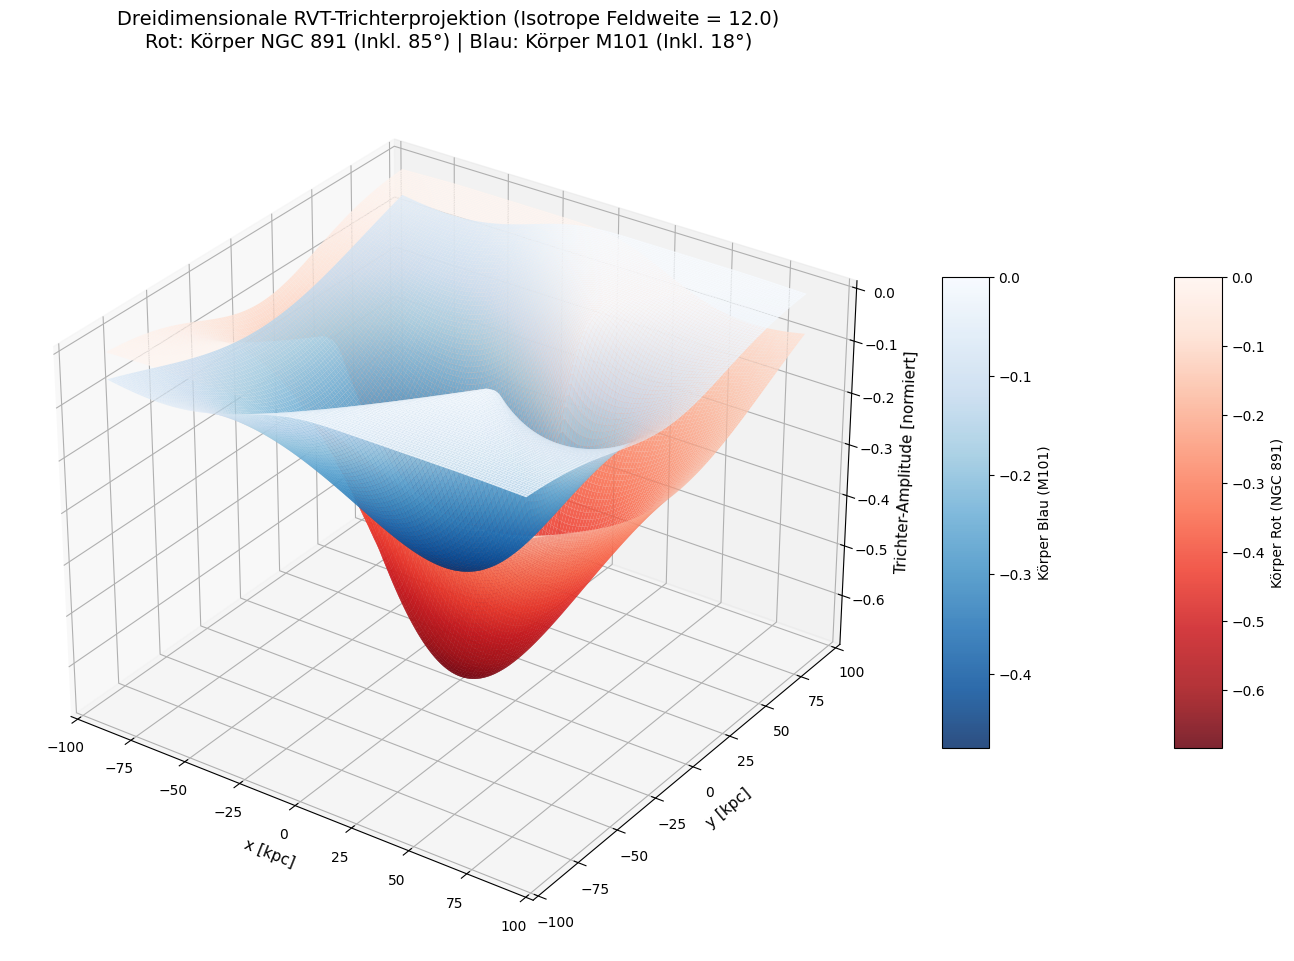

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# ============================================================
# DREIDIMENSIONALE RVT-TRICHTER-PROJEKTION (ZELLE 4 ERWEITERT)
# ROTER KÖRPER (NGC 891) vs. BLAUER KÖRPER (M101)
# ISOTROPE SKALIERUNG FÜR BEIDE KÖRPER
# ============================================================

# Parameter
N = 140
L = 180.0
C_RVT = 0.8
target_angle_deg = 90.0
target_angle = np.radians(target_angle_deg)
length_scale = 28.0

# Galaxien-Zentren (2D-Ebene für den Trichter-Plot)
center_891_2d = (-35.0, 0.0)
center_M101_2d = (35.0, 0.0)

# --- EXAKT IDENTISCHE ISOTROPE SKALIERUNG ---
scale_ref = 12.0

# Inklinationsfaktoren
gamma_891 = 1.0 + C_RVT * np.sin(np.radians(85.0))
gamma_M101 = 1.0 + C_RVT * np.sin(np.radians(18.0))
gamma_90 = 1.0 + C_RVT * np.sin(target_angle)

# Amplituden-Skalierung
amp_incl = 1.0
amp_891_incl = amp_incl * (gamma_891 / gamma_90)
amp_M101_incl = amp_incl * (gamma_M101 / gamma_90)

# Gitter für die 2D-Grundfläche
x = np.linspace(-L / 2, L / 2, N)
y = np.linspace(-L / 2, L / 2, N)
X2, Y2 = np.meshgrid(x, y, indexing='ij')

# ------------------------------------------------------------
# Getrennte Trichterberechnung für die Körper (Einheitliches scale_ref)
# ------------------------------------------------------------
def compute_single_funnels(X2, Y2):
    xL, yL = center_891_2d
    xR, yR = center_M101_2d

    XL = X2 - xL
    YL = Y2 - yL
    XR = X2 - xR
    YR = Y2 - yR

    opening = np.sin(target_angle)

    # Flussrichtungen
    forward_L = 1.0 / (1.0 + np.exp(-XL / length_scale))
    forward_R = 1.0 / (1.0 + np.exp(XR / length_scale))

    # Breitenwachstum mit IDENTISCHER Skalierung
    radial_width_L = scale_ref * (1.0 + np.abs(XL) / length_scale)
    radial_width_R = scale_ref * (1.0 + np.abs(XR) / length_scale)

    # Linker Körper (NGC 891) - Rot
    funnel_L = (
        -amp_891_incl
        * opening
        * forward_L
        * np.exp(-(YL**2) / (2.0 * radial_width_L**2))
        * np.exp(-(XL**2) / (2.0 * (2.5 * length_scale)**2))
    )

    # Rechter Körper (M101) - Blau
    funnel_R = (
        -amp_M101_incl
        * opening
        * forward_R
        * np.exp(-(YR**2) / (2.0 * radial_width_R**2))
        * np.exp(-(XR**2) / (2.0 * (2.5 * length_scale)**2))
    )

    return funnel_L, funnel_R

funnel_red, funnel_blue = compute_single_funnels(X2, Y2)

# ------------------------------------------------------------
# 3D Plot-Erstellung
# ------------------------------------------------------------
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(1, 1, 1, projection='3d')

# 1. Roter Körper: NGC 891 (Linker Trichter)
surf_red = ax.plot_surface(
    X2, Y2, funnel_red,
    cmap=cm.Reds_r,
    linewidth=0,
    antialiased=True,
    alpha=0.85,
    rcount=N, ccount=N
)

# 2. Blauer Körper: M101 (Rechter Trichter)
surf_blue = ax.plot_surface(
    X2, Y2, funnel_blue,
    cmap=cm.Blues_r,
    linewidth=0,
    antialiased=True,
    alpha=0.85,
    rcount=N, ccount=N
)

# Design und Achsenbeschriftung mit Klarnamen
ax.set_title(
    'Dreidimensionale RVT-Trichterprojektion (Isotrope Feldweite = 12.0)\n'
    'Rot: Körper NGC 891 (Inkl. 85°) | Blau: Körper M101 (Inkl. 18°)',
    fontsize=14, pad=20
)
ax.set_xlabel('x [kpc]', fontsize=11)
ax.set_ylabel('y [kpc]', fontsize=11)
ax.set_zlabel('Trichter-Amplitude [normiert]', fontsize=11)

# Ansichtswinkel
ax.view_init(elev=30, azim=-55)

# Farbbalken
fig.colorbar(surf_red, ax=ax, shrink=0.5, aspect=10, label='Körper Rot (NGC 891)')
fig.colorbar(surf_blue, ax=ax, shrink=0.5, aspect=10, label='Körper Blau (M101)')

plt.tight_layout()
plt.savefig('RVT_3D_Trichter_Koerper_Rot_Blau_Isotrop.png', dpi=300)
plt.show()

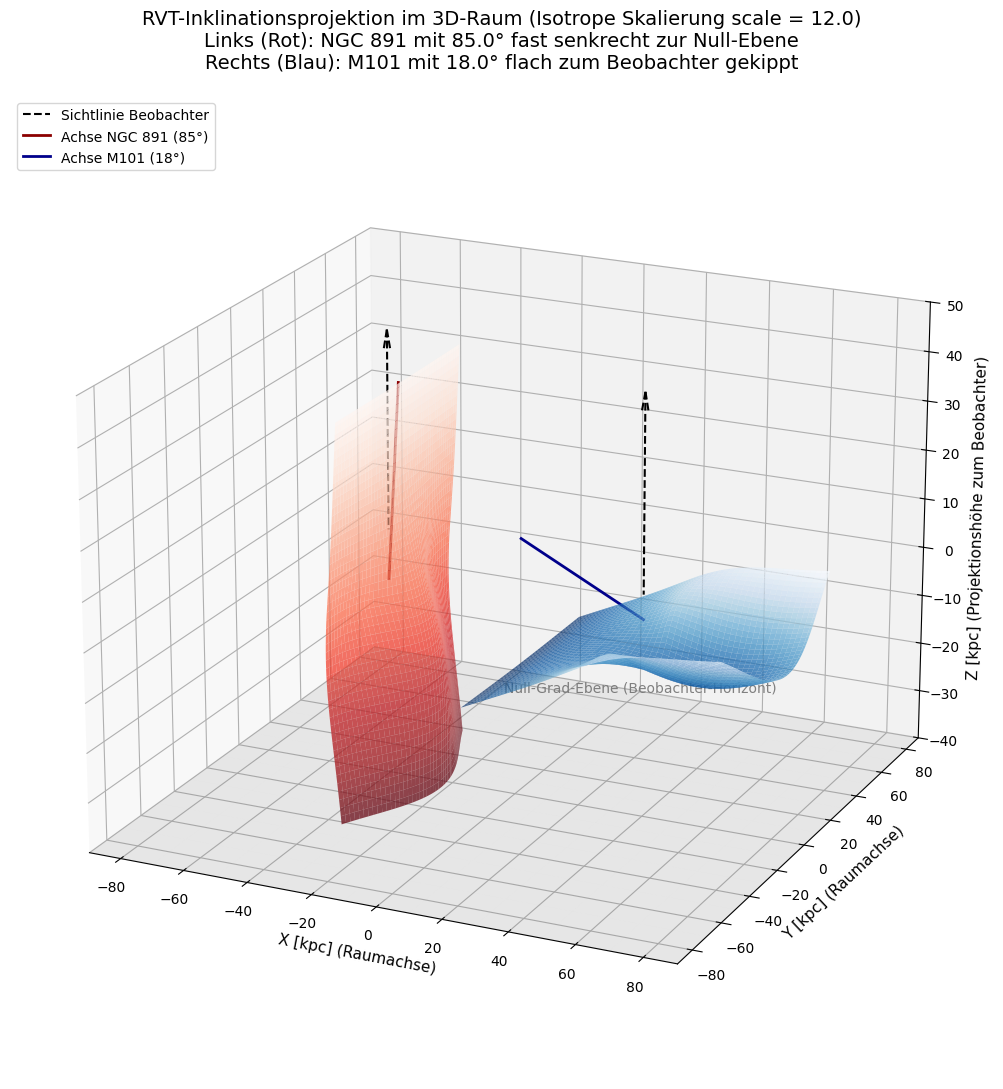

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# ============================================================
# 3D-RVT-PROJEKTION: INKLINATIONSAUSRICHTUNG ZUM BEOBACHTER
# Rot: NGC 891 (85° geneigt, fast Edge-On zum Beobachter)
# Blau: M101 (18° geneigt, fast Face-On zum Beobachter)
# ISOTROPE SKALIERUNG (scale_ref = 12.0)
# ============================================================

N = 100
L = 180.0
length_scale = 28.0

# Neigungswinkel zum Beobachter (Null-Grad-Ebene bei z=0)
inc_891_deg = 85.0
inc_M101_deg = 18.0

rad_891 = np.radians(inc_891_deg)
rad_M101 = np.radians(inc_M101_deg)

# Zentren der Körper auf der x-Achse
x_891 = -40.0
x_M101 = 40.0

# --- EINHEITLICHE ISOTROPE SKALIERUNG ---
scale_ref = 12.0

# Lokales Gitter für die Trichtererzeugung (vor Rotation)
u = np.linspace(-40, 40, N)
v = np.linspace(-40, 40, N)
U, V = np.meshgrid(u, v, indexing='ij')

# ------------------------------------------------------------
# Mathematische Trichtergeometrie (lokales System)
# ------------------------------------------------------------
def local_funnel(U, V, scale, amp):
    # Öffnung entlang der lokalen U-Achse
    forward = 1.0 / (1.0 + np.exp(U / 10.0))
    radial_width = scale * (1.0 + np.abs(U) / length_scale)
    return -amp * forward * np.exp(-(V**2) / (2.0 * radial_width**2))

# Erzeuge die lokalen Amplitudenprofile (BEIDE MIT scale_ref = 12.0)
Z_891_local = local_funnel(U, V, scale=scale_ref, amp=20.0)
Z_M101_local = local_funnel(-U, V, scale=scale_ref, amp=20.0) # Entgegengesetzte Öffnung

# ------------------------------------------------------------
# 3D-Rotation und Projektion auf die Beobachter-Ebene
# ------------------------------------------------------------
# Rotationsmatrix um die Y-Achse (Inklination zum Beobachter)
def rotate_galaxy(U, V, Z_local, angle_rad, x_offset):
    # Rotationsformel für die Neigung gegen die z-Ebene
    X_rot = U * np.cos(angle_rad) - Z_local * np.sin(angle_rad) + x_offset
    Y_rot = V
    Z_rot = U * np.sin(angle_rad) + Z_local * np.cos(angle_rad)
    return X_rot, Y_rot, Z_rot

X_891, Y_891, Z_891 = rotate_galaxy(U, V, Z_891_local, rad_891, x_891)
X_M101, Y_M101, Z_M101 = rotate_galaxy(U, V, Z_M101_local, rad_M101, x_M101)

# ------------------------------------------------------------
# 3D-Szenen-Aufbau
# ------------------------------------------------------------
fig = plt.figure(figsize=(16, 11))
ax = fig.add_subplot(1, 1, 1, projection='3d')

# 1. Null-Grad-Ebene des Beobachters (Referenzfläche bei z = -40 für bessere Sichtbarkeit)
z_floor = -40
x_floor = np.linspace(-L/2, L/2, 10)
y_floor = np.linspace(-L/2, L/2, 10)
X_f, Y_f = np.meshgrid(x_floor, y_floor)
ax.plot_surface(X_f, Y_f, np.full_like(X_f, z_floor), alpha=0.1, color='gray')
ax.text(0, L/2, z_floor, "Null-Grad-Ebene (Beobachter-Horizont)", color='gray', ha='center')

# 2. Roter Körper (NGC 891) - Stark aufgerichtet (85°)
surf_red = ax.plot_surface(
    X_891, Y_891, Z_891,
    cmap=cm.Reds_r, linewidth=0, antialiased=True, alpha=0.75
)

# 3. Blauer Körper (M101) - Flach geneigt (18°)
surf_blue = ax.plot_surface(
    X_M101, Y_M101, Z_M101,
    cmap=cm.Blues_r, linewidth=0, antialiased=True, alpha=0.75
)

# 4. Projektionspfeile / Sichtlinien zum Beobachter
ax.quiver([x_891, x_M101], [0, 0], [10, 5], [0, 0], [0, 0], [40, 40],
          color='black', linestyle='--', linewidth=1.5, arrow_length_ratio=0.1, label='Sichtlinie Beobachter')

# Symmetrie-Achsen der Körper einzeichnen
ax.plot([x_891, x_891 + 40 * np.cos(rad_891)], [0, 0], [0, 40 * np.sin(rad_891)], color='darkred', lw=2, label='Achse NGC 891 (85°)')
ax.plot([x_M101, x_M101 - 40 * np.cos(rad_M101)], [0, 0], [0, 40 * np.sin(rad_M101)], color='darkblue', lw=2, label='Achse M101 (18°)')

# Achsen-Konfiguration
ax.set_title(
    f'RVT-Inklinationsprojektion im 3D-Raum (Isotrope Skalierung scale = {scale_ref})\n'
    f'Links (Rot): NGC 891 mit {inc_891_deg}° fast senkrecht zur Null-Ebene\n'
    f'Rechts (Blau): M101 mit {inc_M101_deg}° flach zum Beobachter gekippt',
    fontsize=14, pad=20
)
ax.set_xlabel('X [kpc] (Raumachse)', fontsize=11)
ax.set_ylabel('Y [kpc] (Raumachse)', fontsize=11)
ax.set_zlabel('Z [kpc] (Projektionshöhe zum Beobachter)', fontsize=11)

# Kameraposition
ax.view_init(elev=20, azim=-65)

ax.set_xlim(-L/2, L/2)
ax.set_ylim(-L/2, L/2)
ax.set_zlim(z_floor, 50)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('RVT_3D_Inklinations_Projektion_Beobachter_Isotrop.png', dpi=300)
plt.show()

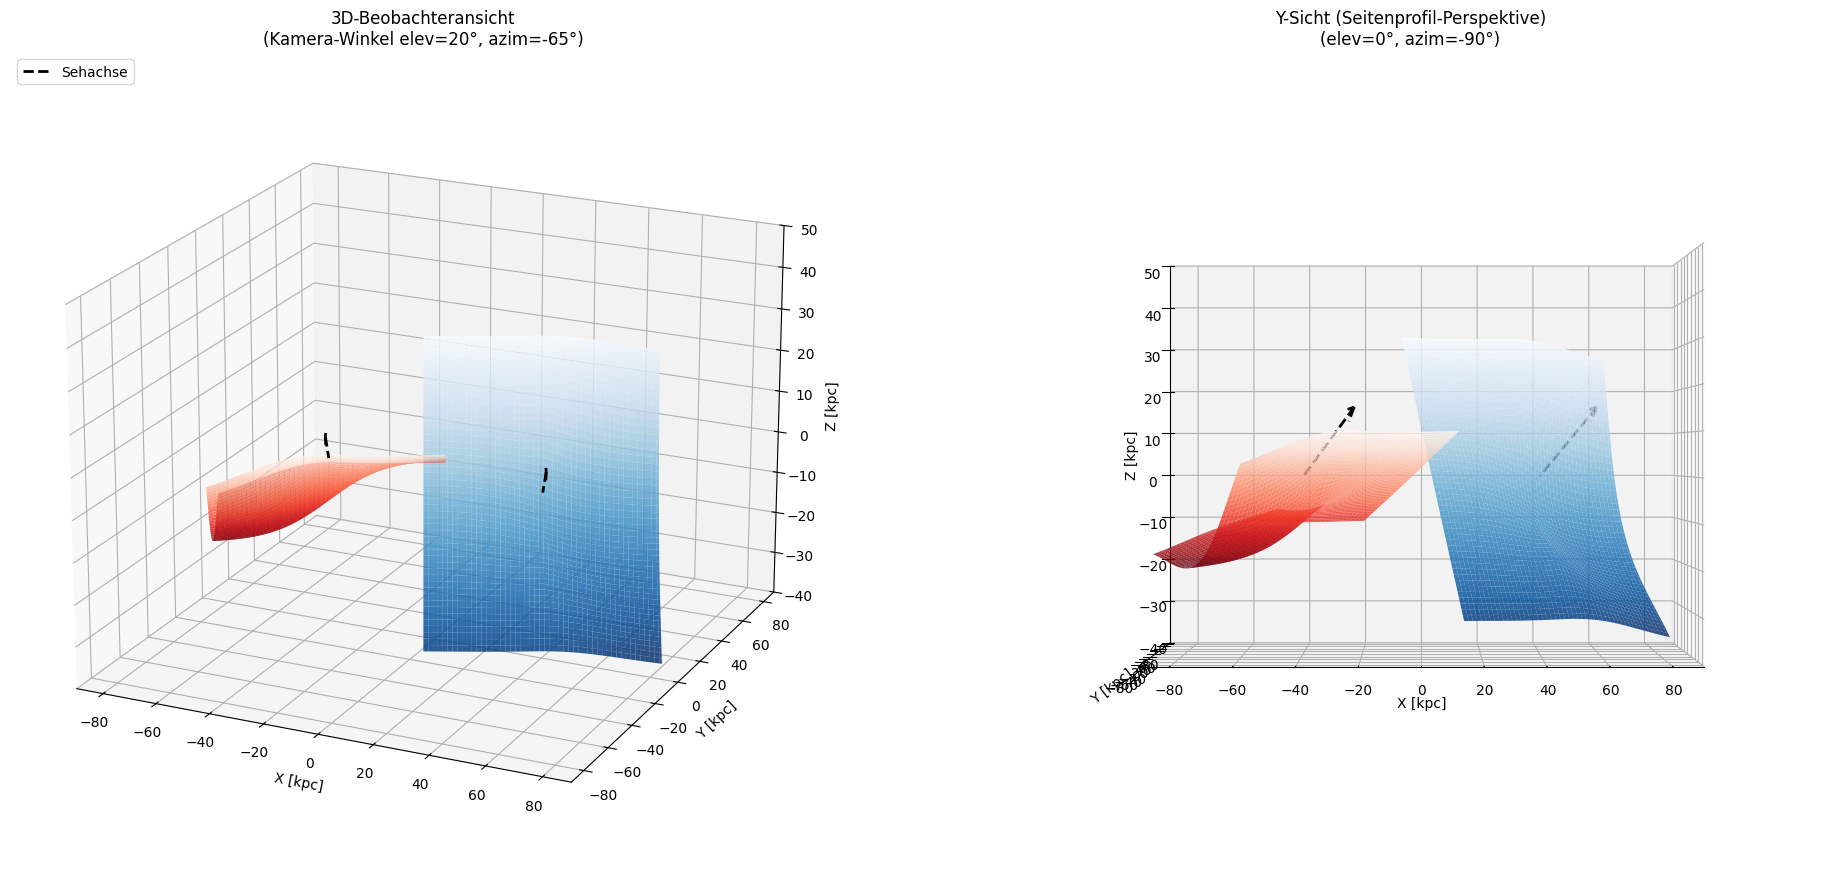

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# ============================================================
# RVT-PROJEKTION: DOPPELBILD MIT Y-SICHT (GLEICHE BERECHNUNG)
# Linkes Bild: 3D-Beobachterperspektive
# Rechtes Bild: Profil/Sicht entlang der Y-Achse
# ============================================================

N = 100
L = 180.0
length_scale = 28.0
scale_ref = 12.0

# Inklinationswinkel (Relativ zur Blickrichtung)
inc_891_deg = 85.0   # Edge-On (Kante)
inc_M101_deg = 18.0  # Face-On (Draufsicht)

# Kamera-Perspektive (Beobachter)
elev_angle = 20.0
azim_angle = -65.0

rad_elev = np.radians(elev_angle)
rad_azim = np.radians(azim_angle)

# Beobachtervektor (Sichtlinie)
v_obs = np.array([
    np.cos(rad_elev) * np.cos(rad_azim),
    np.cos(rad_elev) * np.sin(rad_azim),
    np.sin(rad_elev)
])
v_obs /= np.linalg.norm(v_obs)

# Transformation (identisch zur Hauptberechnung)
def orient_galaxy_to_observer(inc_deg, v_obs):
    inc_rad = np.radians(inc_deg)
    up = np.array([0.0, 0.0, 1.0])
    if np.abs(np.dot(v_obs, up)) > 0.99:
        up = np.array([1.0, 0.0, 0.0])

    rot_axis = np.cross(v_obs, up)
    rot_axis /= np.linalg.norm(rot_axis)

    K = np.array([
        [0, -rot_axis[2], rot_axis[1]],
        [rot_axis[2], 0, -rot_axis[0]],
        [-rot_axis[1], rot_axis[0], 0]
    ])

    R_inc = np.eye(3) + np.sin(inc_rad) * K + (1 - np.cos(inc_rad)) * np.dot(K, K)

    z_prime = v_obs
    x_prime = np.cross(up, z_prime)
    x_prime /= np.linalg.norm(x_prime)
    y_prime = np.cross(z_prime, x_prime)

    R_align = np.column_stack([x_prime, y_prime, z_prime])
    return R_inc @ R_align

u = np.linspace(-40, 40, N)
v = np.linspace(-40, 40, N)
U, V = np.meshgrid(u, v, indexing='ij')

def local_funnel(U, V, scale, amp):
    forward = 1.0 / (1.0 + np.exp(U / 10.0))
    radial_width = scale * (1.0 + np.abs(U) / length_scale)
    return -amp * forward * np.exp(-(V**2) / (2.0 * radial_width**2))

Z_891_local = local_funnel(U, V, scale=scale_ref, amp=20.0)
Z_M101_local = local_funnel(-U, V, scale=scale_ref, amp=20.0)

def transform_mesh(U, V, Z_local, inc_deg, x_offset, v_obs):
    R = orient_galaxy_to_observer(inc_deg, v_obs)
    pts = np.vstack([U.ravel(), V.ravel(), Z_local.ravel()])
    pts_rot = R @ pts

    X_rot = pts_rot[0, :].reshape(U.shape) + x_offset
    Y_rot = pts_rot[1, :].reshape(U.shape)
    Z_rot = pts_rot[2, :].reshape(U.shape)
    return X_rot, Y_rot, Z_rot

x_891, x_M101 = -40.0, 40.0

X_891, Y_891, Z_891 = transform_mesh(U, V, Z_891_local, inc_891_deg, x_891, v_obs)
X_M101, Y_M101, Z_M101 = transform_mesh(U, V, Z_M101_local, inc_M101_deg, x_M101, v_obs)

# ------------------------------------------------------------
# VISUALISIERUNG: DOPPEL-DIAGRAMM (3D-Perspektive & Y-Sicht)
# ------------------------------------------------------------
fig = plt.figure(figsize=(20, 9))
z_floor = -40
arrow_len = 45.0

# --- BILD 1: 3D-Kameraperspektive ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_891, Y_891, Z_891, cmap=cm.Reds_r, linewidth=0, alpha=0.85)
ax1.plot_surface(X_M101, Y_M101, Z_M101, cmap=cm.Blues_r, linewidth=0, alpha=0.85)
ax1.quiver([x_891, x_M101], [0, 0], [0, 0],
           [v_obs[0]*arrow_len]*2, [v_obs[1]*arrow_len]*2, [v_obs[2]*arrow_len]*2,
           color='black', linestyle='--', linewidth=2.0, arrow_length_ratio=0.12,
           label='Sehachse')

ax1.set_title('3D-Beobachteransicht\n(Kamera-Winkel elev=20°, azim=-65°)', fontsize=12)
ax1.set_xlabel('X [kpc]')
ax1.set_ylabel('Y [kpc]')
ax1.set_zlabel('Z [kpc]')
ax1.view_init(elev=elev_angle, azim=azim_angle)
ax1.set_xlim(-L/2, L/2)
ax1.set_ylim(-L/2, L/2)
ax1.set_zlim(z_floor, 50)
ax1.legend(loc='upper left')

# --- BILD 2: Y-Sicht (Seitenansicht entlang der Y-Achse) ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_891, Y_891, Z_891, cmap=cm.Reds_r, linewidth=0, alpha=0.85)
ax2.plot_surface(X_M101, Y_M101, Z_M101, cmap=cm.Blues_r, linewidth=0, alpha=0.85)
ax2.quiver([x_891, x_M101], [0, 0], [0, 0],
           [v_obs[0]*arrow_len]*2, [v_obs[1]*arrow_len]*2, [v_obs[2]*arrow_len]*2,
           color='black', linestyle='--', linewidth=2.0, arrow_length_ratio=0.12)

# Exakte Y-Sicht: elev=0°, azim=-90° (Sehen direkt parallel zur Y-Achse auf die X-Z-Ebene)
ax2.set_title('Y-Sicht (Seitenprofil-Perspektive)\n(elev=0°, azim=-90°)', fontsize=12)
ax2.set_xlabel('X [kpc]')
ax2.set_ylabel('Y [kpc]')
ax2.set_zlabel('Z [kpc]')
ax2.view_init(elev=0, azim=-90)
ax2.set_xlim(-L/2, L/2)
ax2.set_ylim(-L/2, L/2)
ax2.set_zlim(z_floor, 50)

plt.tight_layout()
plt.savefig('RVT_Koppelung_Doppelansicht_YSicht.png', dpi=300)
plt.show()

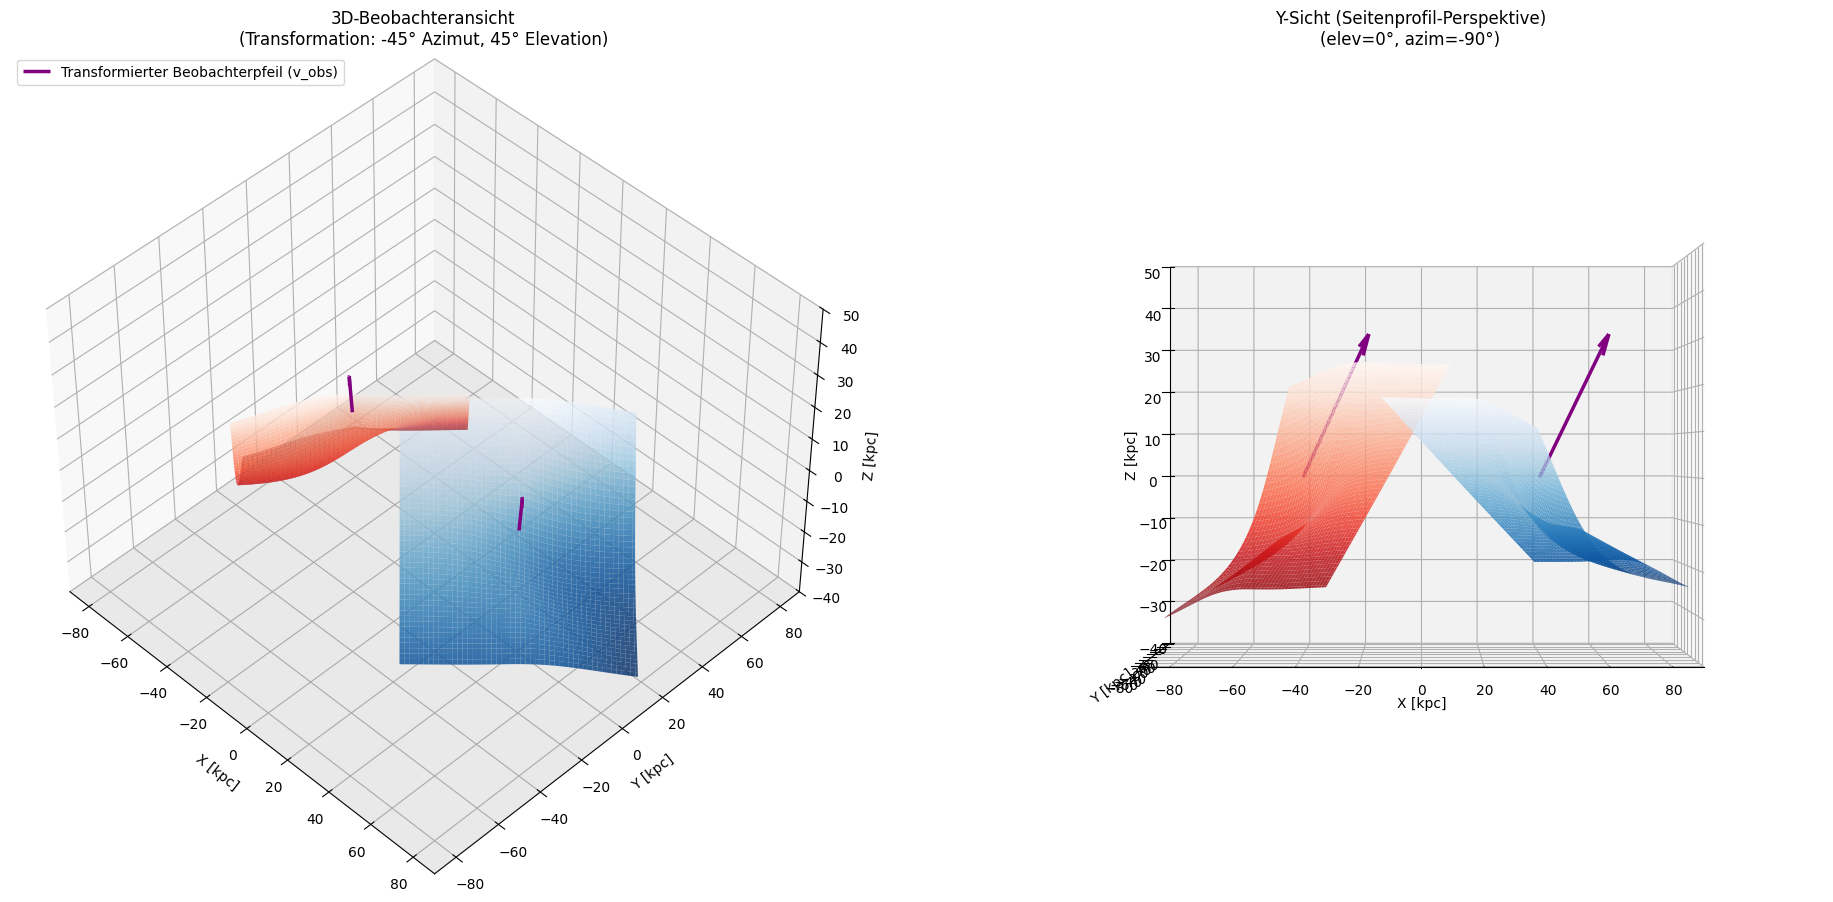

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# ============================================================
# ZELLE 1: VORGELAGERTE RECHNUNG (TRANSFORMATION & BEOBACHTER)
# ============================================================

# --- Parameter ---
N = 100
L = 180.0
length_scale = 28.0
scale_ref = 12.0

# Inklinationswinkel (Relativ zur Blickrichtung)
inc_891_deg = 85.0   # Edge-On (Kante)
inc_M101_deg = 18.0  # Face-On (Draufsicht)

# Netto-Drehung & Erhöhung für den Beobachtervektor
azimuth_deg = -45.0   # Netto: 90° links (-90°) + 45° rechts (+45°)
elevation_deg = 45.0  # Erhöhung (Elevation)

azimuth_rad = np.radians(azimuth_deg)
elevation_rad = np.radians(elevation_deg)

# Normierter Richtungsvektor des transformierten Beobachters (v_obs)
dx_norm = np.cos(elevation_rad) * np.cos(azimuth_rad)
dy_norm = np.cos(elevation_rad) * np.sin(azimuth_rad)
dz_norm = np.sin(elevation_rad)

v_obs = np.array([dx_norm, dy_norm, dz_norm])
v_obs /= np.linalg.norm(v_obs)

# Exakte Orientierungsmatrix relativ zum Beobachtervektor
def orient_galaxy_to_observer(inc_deg, v_obs):
    inc_rad = np.radians(inc_deg)
    up = np.array([0.0, 0.0, 1.0])
    if np.abs(np.dot(v_obs, up)) > 0.99:
        up = np.array([1.0, 0.0, 0.0])

    rot_axis = np.cross(v_obs, up)
    rot_axis /= np.linalg.norm(rot_axis)

    K = np.array([
        [0, -rot_axis[2], rot_axis[1]],
        [rot_axis[2], 0, -rot_axis[0]],
        [-rot_axis[1], rot_axis[0], 0]
    ])

    R_inc = np.eye(3) + np.sin(inc_rad) * K + (1 - np.cos(inc_rad)) * np.dot(K, K)

    z_prime = v_obs
    x_prime = np.cross(up, z_prime)
    x_prime /= np.linalg.norm(x_prime)
    y_prime = np.cross(z_prime, x_prime)

    R_align = np.column_stack([x_prime, y_prime, z_prime])
    return R_inc @ R_align

# --- Gitter & Lokale Funnel-Berechnung ---
u = np.linspace(-40, 40, N)
v = np.linspace(-40, 40, N)
U, V = np.meshgrid(u, v, indexing='ij')

def local_funnel(U, V, scale, amp):
    forward = 1.0 / (1.0 + np.exp(U / 10.0))
    radial_width = scale * (1.0 + np.abs(U) / length_scale)
    return -amp * forward * np.exp(-(V**2) / (2.0 * radial_width**2))

Z_891_local = local_funnel(U, V, scale=scale_ref, amp=20.0)
Z_M101_local = local_funnel(-U, V, scale=scale_ref, amp=20.0)

# --- Mesh-Transformation in den Raum ---
def transform_mesh(U, V, Z_local, inc_deg, x_offset, v_obs):
    R = orient_galaxy_to_observer(inc_deg, v_obs)
    pts = np.vstack([U.ravel(), V.ravel(), Z_local.ravel()])
    pts_rot = R @ pts

    X_rot = pts_rot[0, :].reshape(U.shape) + x_offset
    Y_rot = pts_rot[1, :].reshape(U.shape)
    Z_rot = pts_rot[2, :].reshape(U.shape)
    return X_rot, Y_rot, Z_rot

x_891, x_M101 = -40.0, 40.0

X_891, Y_891, Z_891 = transform_mesh(U, V, Z_891_local, inc_891_deg, x_891, v_obs)
X_M101, Y_M101, Z_M101 = transform_mesh(U, V, Z_M101_local, inc_M101_deg, x_M101, v_obs)


# ============================================================
# ZELLE 2: NAHTLOS ANGESCHLOSSENE VISUALISIERUNG (DOPPEL-PLOT)
# ============================================================

fig = plt.figure(figsize=(20, 9))
z_floor = -40
arrow_scale = 45.0

# Pfeilvektoren für die Visualisierung aus den vorgelagerten v_obs Daten
dx_arrow = v_obs[0] * arrow_scale
dy_arrow = v_obs[1] * arrow_scale
dz_arrow = v_obs[2] * arrow_scale

# --- BILD 1: 3D-Perspektive mit transformierter Blickrichtung ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

# Bezugsebene am Boden
x_floor = np.linspace(-L/2, L/2, 10)
y_floor = np.linspace(-L/2, L/2, 10)
X_f, Y_f = np.meshgrid(x_floor, y_floor)
ax1.plot_surface(X_f, Y_f, np.full_like(X_f, z_floor), alpha=0.08, color='gray')

# Galaxienflächen
ax1.plot_surface(X_891, Y_891, Z_891, cmap=cm.Reds_r, linewidth=0, alpha=0.85)
ax1.plot_surface(X_M101, Y_M101, Z_M101, cmap=cm.Blues_r, linewidth=0, alpha=0.85)

# Transformierte Beobachterpfeile
ax1.quiver([x_891, x_M101], [0, 0], [0, 0],
           [dx_arrow]*2, [dy_arrow]*2, [dz_arrow]*2,
           color='purple', linestyle='-', linewidth=2.5, arrow_length_ratio=0.12,
           label='Transformierter Beobachterpfeil (v_obs)')

ax1.set_title('3D-Beobachteransicht\n(Transformation: -45° Azimut, 45° Elevation)', fontsize=12)
ax1.set_xlabel('X [kpc]')
ax1.set_ylabel('Y [kpc]')
ax1.set_zlabel('Z [kpc]')
ax1.view_init(elev=elevation_deg, azim=azimuth_deg)
ax1.set_xlim(-L/2, L/2)
ax1.set_ylim(-L/2, L/2)
ax1.set_zlim(z_floor, 50)
ax1.legend(loc='upper left')

# --- BILD 2: Y-Sicht (Seitenansicht entlang der Y-Achse) ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

# Galaxienflächen
ax2.plot_surface(X_891, Y_891, Z_891, cmap=cm.Reds_r, linewidth=0, alpha=0.85)
ax2.plot_surface(X_M101, Y_M101, Z_M101, cmap=cm.Blues_r, linewidth=0, alpha=0.85)

# Transformierte Beobachterpfeile
ax2.quiver([x_891, x_M101], [0, 0], [0, 0],
           [dx_arrow]*2, [dy_arrow]*2, [dz_arrow]*2,
           color='purple', linestyle='-', linewidth=2.5, arrow_length_ratio=0.12)

# Exakte Y-Sicht (Blick orthogonal zur Y-Achse)
ax2.set_title('Y-Sicht (Seitenprofil-Perspektive)\n(elev=0°, azim=-90°)', fontsize=12)
ax2.set_xlabel('X [kpc]')
ax2.set_ylabel('Y [kpc]')
ax2.set_zlabel('Z [kpc]')
ax2.view_init(elev=0, azim=-90)
ax2.set_xlim(-L/2, L/2)
ax2.set_ylim(-L/2, L/2)
ax2.set_zlim(z_floor, 50)

plt.tight_layout()
plt.savefig('RVT_Koppelung_Vollstaendig_Integriert.png', dpi=300)
plt.show()

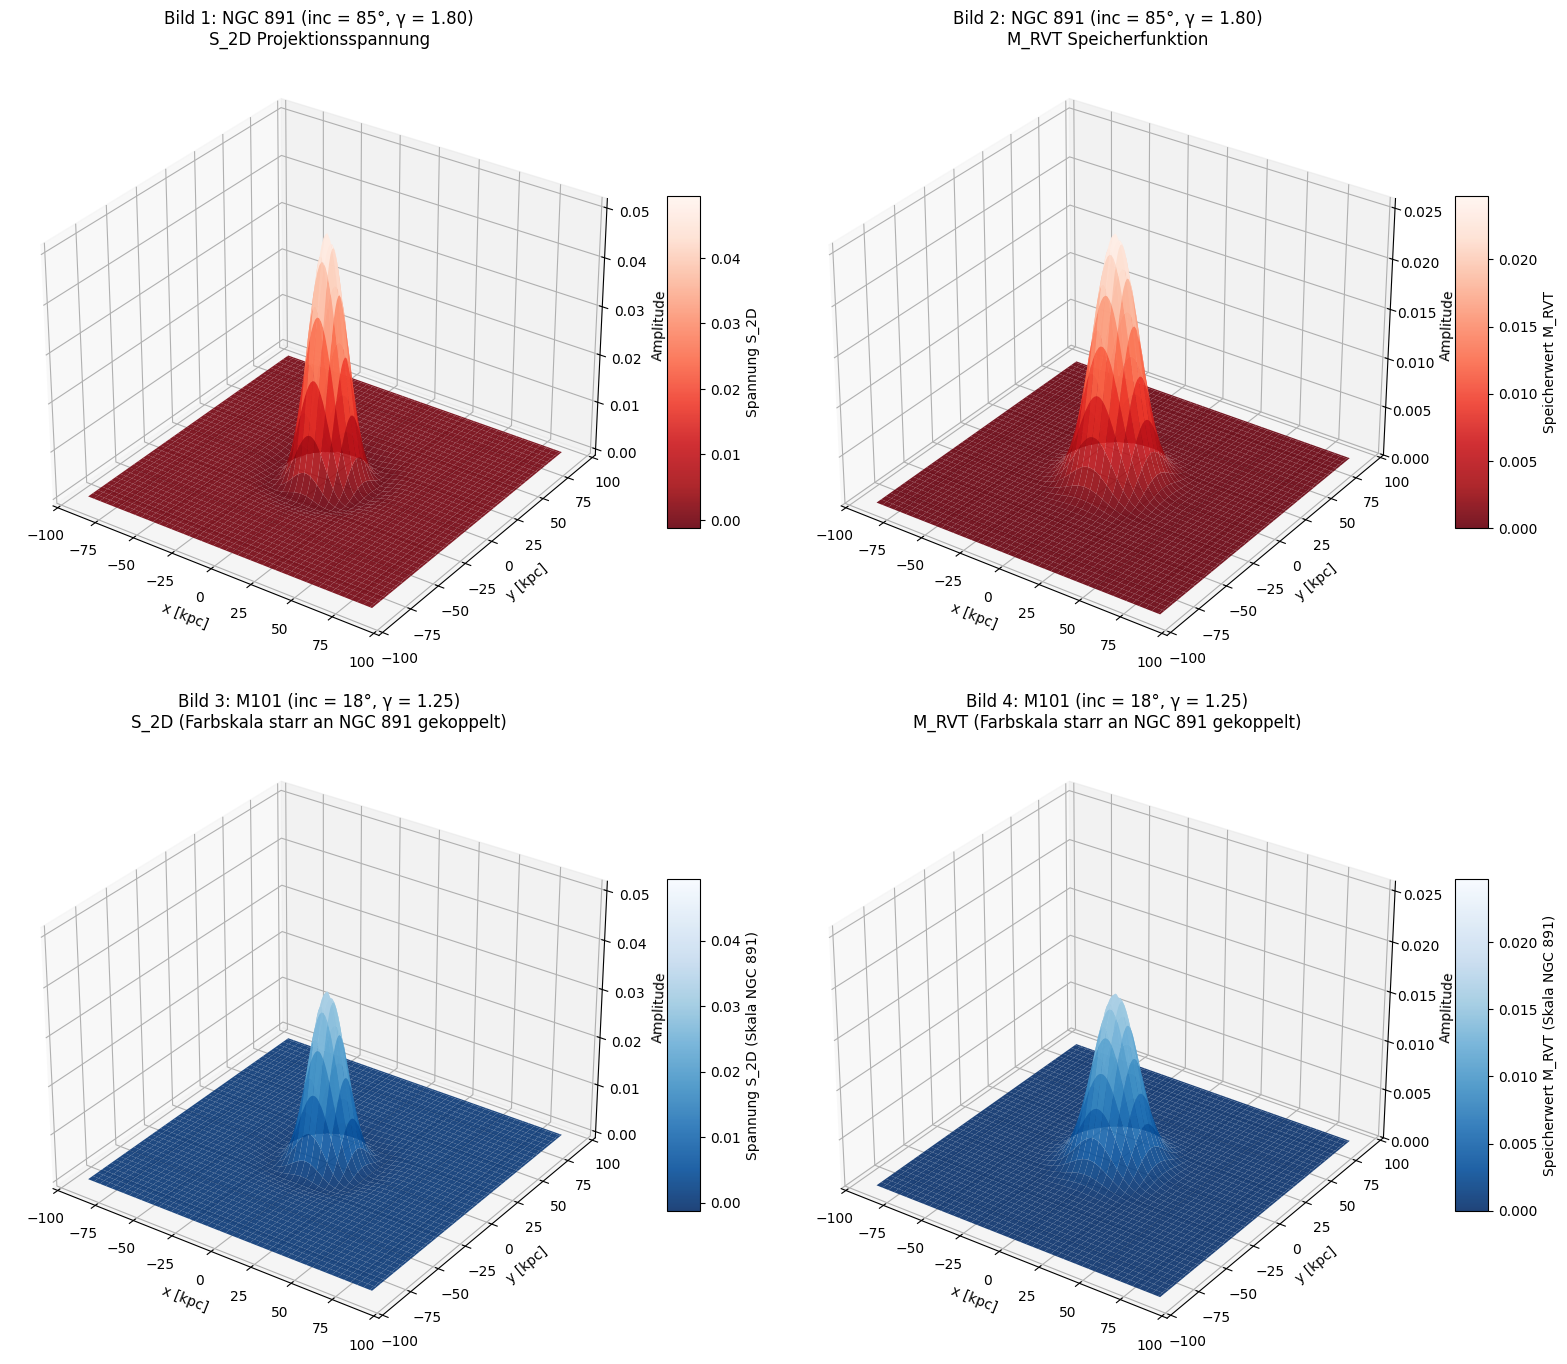

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from mpl_toolkits.mplot3d import Axes3D

# ============================================================
# 1. PARAMETER UND INKLINATIONS-ROTIERTE MATRIZEN
# ============================================================
N = 140
L = 180.0
C_RVT = 0.8
scale_ref = 12.0

inc_891_deg = 85.0
inc_M101_deg = 18.0

# Gammas
gamma_891 = 1.0 + C_RVT * np.sin(np.radians(inc_891_deg))   # ~ 1.797 (Referenz)
gamma_M101 = 1.0 + C_RVT * np.sin(np.radians(inc_M101_deg))  # ~ 1.247

def get_rot_matrix(inc_deg):
    inc_rad = np.radians(inc_deg)
    return np.array([
        [1, 0, 0],
        [0, np.cos(inc_rad), -np.sin(inc_rad)],
        [0, np.sin(inc_rad),  np.cos(inc_rad)]
    ])

# Gitter
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
z = np.linspace(-L/2, L/2, N)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

dx = L / (N - 1)

# ============================================================
# 2. TOPOGRAFIE BERECHNUNG
# ============================================================
def compute_rvt_topography_exact(inc_deg, gamma_factor):
    R_inc = get_rot_matrix(inc_deg)

    pts = np.vstack([X.ravel(), Y.ravel(), Z.ravel()])
    pts_rot = R_inc @ pts

    X_rot = pts_rot[0, :].reshape(X.shape)
    Y_rot = pts_rot[1, :].reshape(Y.shape)
    Z_rot = pts_rot[2, :].reshape(Z.shape)

    Xi = gamma_factor * np.exp(-(X_rot**2 + Y_rot**2 + Z_rot**2) / (2.0 * scale_ref**2))

    laplace_Xi = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) +
                  np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) +
                  np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) -
                  6 * Xi) / (dx**2)

    E_xx = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) - 2 * Xi) / (dx**2) - laplace_Xi
    E_yy = (np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) - 2 * Xi) / (dx**2) - laplace_Xi
    E_zz = (np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) - 2 * Xi) / (dx**2) - laplace_Xi

    S_2D = E_xx + E_yy
    S_perp = E_zz
    M_RVT = S_2D - S_perp

    z_slice = N // 2
    return S_2D[:, :, z_slice], M_RVT[:, :, z_slice]

# Auswertung
S_2D_891, M_RVT_891 = compute_rvt_topography_exact(inc_891_deg, gamma_891)
S_2D_M101, M_RVT_M101 = compute_rvt_topography_exact(inc_M101_deg, gamma_M101)

# ============================================================
# 3. STARRE FARB- UND ACHSEN-LIMITS VON NGC 891 FESTLEGEN!
# ============================================================
vmin_S2D, vmax_S2D = np.min(S_2D_891), np.max(S_2D_891)
vmin_MRVT, vmax_MRVT = np.min(M_RVT_891), np.max(M_RVT_891)

zlim_S2D = (vmin_S2D * 1.05, vmax_S2D * 1.05)
zlim_MRVT = (vmin_MRVT * 1.05, vmax_MRVT * 1.05)

X2D, Y2D = np.meshgrid(x, y, indexing='ij')

# ============================================================
# 4. PLOT-GENERIERUNG MIT IDENTISCHEN FARBSKALEN RECHTS
# ============================================================
fig = plt.figure(figsize=(16, 14))

# --- BILD 1: NGC 891 - S_2D ---
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X2D, Y2D, S_2D_891, cmap='Reds_r', alpha=0.9, edgecolor='none',
                         vmin=vmin_S2D, vmax=vmax_S2D)
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label='Spannung S_2D')
ax1.set_title(f'Bild 1: NGC 891 (inc = 85°, γ = {gamma_891:.2f})\nS_2D Projektionsspannung', fontsize=12)
ax1.set_xlabel('x [kpc]'); ax1.set_ylabel('y [kpc]'); ax1.set_zlabel('Amplitude')
ax1.set_zlim(zlim_S2D)
ax1.view_init(elev=30, azim=-55)

# --- BILD 2: NGC 891 - M_RVT ---
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X2D, Y2D, M_RVT_891, cmap='Reds_r', alpha=0.9, edgecolor='none',
                         vmin=vmin_MRVT, vmax=vmax_MRVT)
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label='Speicherwert M_RVT')
ax2.set_title(f'Bild 2: NGC 891 (inc = 85°, γ = {gamma_891:.2f})\nM_RVT Speicherfunktion', fontsize=12)
ax2.set_xlabel('x [kpc]'); ax2.set_ylabel('y [kpc]'); ax2.set_zlabel('Amplitude')
ax2.set_zlim(zlim_MRVT)
ax2.view_init(elev=30, azim=-55)

# --- BILD 3: M101 - S_2D (FARBSKALA STARR VON NGC 891!) ---
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
surf3 = ax3.plot_surface(X2D, Y2D, S_2D_M101, cmap='Blues_r', alpha=0.9, edgecolor='none',
                         vmin=vmin_S2D, vmax=vmax_S2D)  # STARR ERZWUNGEN!
fig.colorbar(surf3, ax=ax3, shrink=0.5, aspect=10, label='Spannung S_2D (Skala NGC 891)')
ax3.set_title(f'Bild 3: M101 (inc = 18°, γ = {gamma_M101:.2f})\nS_2D (Farbskala starr an NGC 891 gekoppelt)', fontsize=12)
ax3.set_xlabel('x [kpc]'); ax3.set_ylabel('y [kpc]'); ax3.set_zlabel('Amplitude')
ax3.set_zlim(zlim_S2D)
ax3.view_init(elev=30, azim=-55)

# --- BILD 4: M101 - M_RVT (FARBSKALA STARR VON NGC 891!) ---
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
surf4 = ax4.plot_surface(X2D, Y2D, M_RVT_M101, cmap='Blues_r', alpha=0.9, edgecolor='none',
                         vmin=vmin_MRVT, vmax=vmax_MRVT)  # STARR ERZWUNGEN!
fig.colorbar(surf4, ax=ax4, shrink=0.5, aspect=10, label='Speicherwert M_RVT (Skala NGC 891)')
ax4.set_title(f'Bild 4: M101 (inc = 18°, γ = {gamma_M101:.2f})\nM_RVT (Farbskala starr an NGC 891 gekoppelt)', fontsize=12)
ax4.set_xlabel('x [kpc]'); ax4.set_ylabel('y [kpc]'); ax4.set_zlabel('Amplitude')
ax4.set_zlim(zlim_MRVT)
ax4.view_init(elev=30, azim=-55)

plt.tight_layout()
plt.savefig('RVT_4_Bilder_Identische_Farbskalen.png', dpi=300)
plt.show()

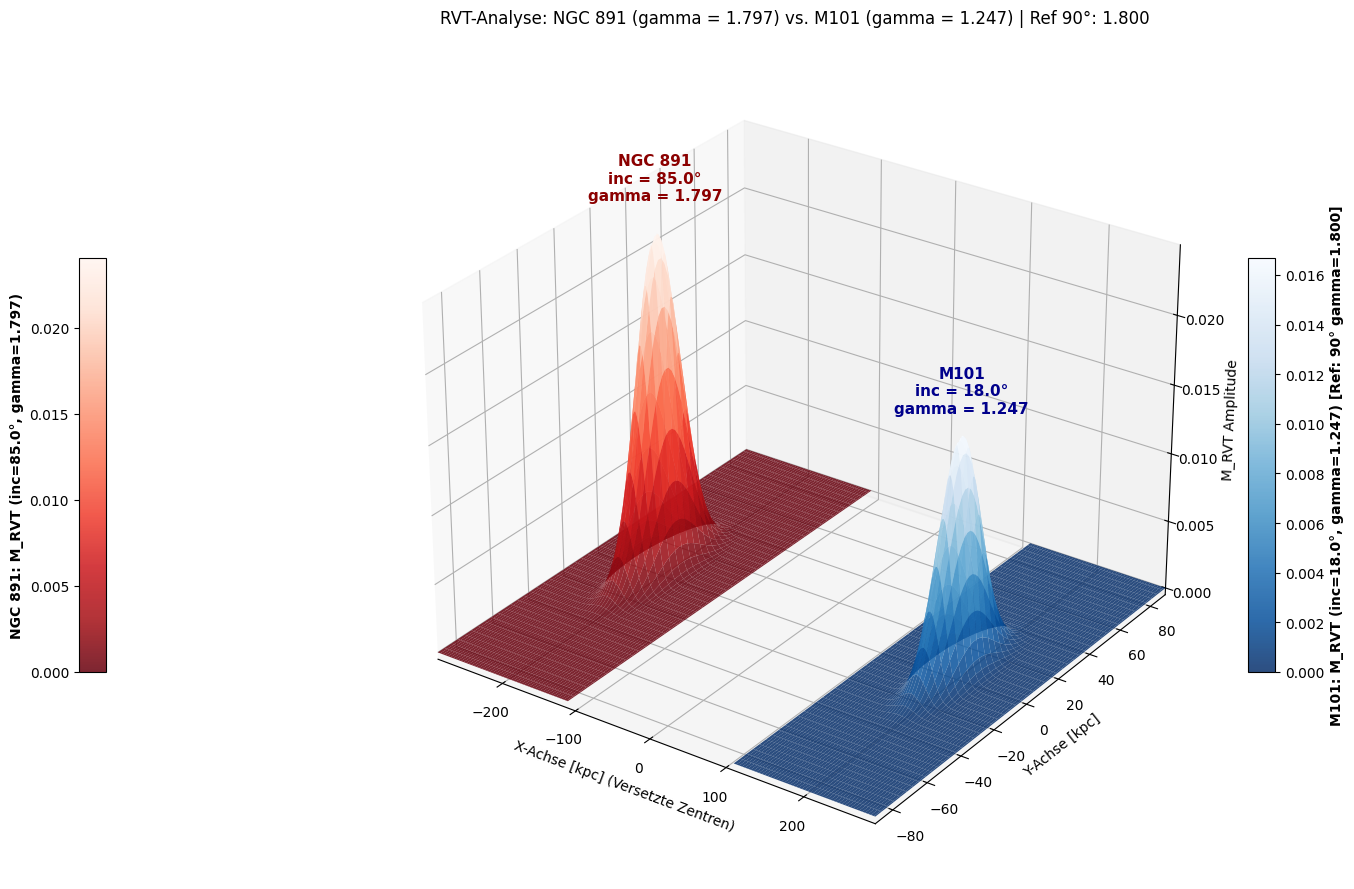

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ============================================================
# 1. PARAMETER UND EXAKTE GAMMA-ZIELAUSRICHTUNG
# ============================================================
N = 100            # Gitterpunkte
L = 180.0          # Systemgröße (kpc)
C_RVT = 0.8
scale_ref = 12.0   # Referenzskala

# Exakte Inklinationswinkel
inc_891_deg = 85.0   # NGC 891
inc_M101_deg = 18.0  # M101

# EXAKTE UNGERUNDETE GAMMA-WERTE GEMÄSS ZIELAUSRICHTUNG
gamma_90   = 1.0 + C_RVT * np.sin(np.radians(90.0))   # 1.800
gamma_891  = 1.0 + C_RVT * np.sin(np.radians(inc_891_deg))   # 1.797
gamma_M101 = 1.0 + C_RVT * np.sin(np.radians(inc_M101_deg))  # 1.247

def get_rot_matrix(inc_deg):
    inc_rad = np.radians(inc_deg)
    return np.array([
        [1, 0, 0],
        [0, np.cos(inc_rad), -np.sin(inc_rad)],
        [0, np.sin(inc_rad),  np.cos(inc_rad)]
    ])

# 3D-Gitter erstellen
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
z = np.linspace(-L/2, L/2, N)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

dx = L / (N - 1)

# ============================================================
# 2. TOPOGRAFIE BERECHNUNG (EXAKTER RVT-TENSOR)
# ============================================================
def compute_rvt_topography(inc_deg, gamma_factor):
    R_inc = get_rot_matrix(inc_deg)

    pts = np.vstack([X.ravel(), Y.ravel(), Z.ravel()])
    pts_rot = R_inc @ pts

    X_rot = pts_rot[0, :].reshape(X.shape)
    Y_rot = pts_rot[1, :].reshape(Y.shape)
    Z_rot = pts_rot[2, :].reshape(Z.shape)

    Xi = gamma_factor * np.exp(-(X_rot**2 + Y_rot**2 + Z_rot**2) / (2.0 * scale_ref**2))

    laplace_Xi = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) +
                  np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) +
                  np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) -
                  6 * Xi) / (dx**2)

    E_xx = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) - 2 * Xi) / (dx**2) - laplace_Xi
    E_yy = (np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) - 2 * Xi) / (dx**2) - laplace_Xi
    E_zz = (np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) - 2 * Xi) / (dx**2) - laplace_Xi

    S_2D = E_xx + E_yy
    S_perp = E_zz
    M_RVT = S_2D - S_perp

    z_slice = N // 2
    return S_2D[:, :, z_slice], M_RVT[:, :, z_slice]

# Auswertung der Tensorschnitte mit ungerundeter Präzision
S_2D_891, M_RVT_891 = compute_rvt_topography(inc_891_deg, gamma_891)
S_2D_M101, M_RVT_M101 = compute_rvt_topography(inc_M101_deg, gamma_M101)

# ============================================================
# 3. GEGENÜBERSTELLUNG IM ZWEI-HÜGEL-3D-BEZUGSRAHMEN
# ============================================================
X2D, Y2D = np.meshgrid(x, y, indexing='ij')

delta_x = 200.0  # Versatz der Zentren im Raum
X_NGC891 = X2D - delta_x  # Linker Hügel: NGC 891
X_M101   = X2D + delta_x  # Rechter Hügel: M101

fig = plt.figure(figsize=(16, 9))
ax = fig.add_subplot(1, 1, 1, projection='3d')

# Linker Hügel: NGC 891 (M_RVT)
surf1 = ax.plot_surface(X_NGC891, Y2D, M_RVT_891, cmap='Reds_r', edgecolor='none', alpha=0.85)

# Rechter Hügel: M101 (M_RVT)
surf2 = ax.plot_surface(X_M101, Y2D, M_RVT_M101, cmap='Blues_r', edgecolor='none', alpha=0.85)

# Text-Markierungen mit EXAKTER 3-Stellen-Formatierung (.3f)
ax.text(-delta_x, 0, np.max(M_RVT_891)*1.1, f"NGC 891\ninc = 85.0°\ngamma = {gamma_891:.3f}",
        color='darkred', fontsize=11, fontweight='bold', ha='center')
ax.text(delta_x, 0, np.max(M_RVT_M101)*1.1, f"M101\ninc = 18.0°\ngamma = {gamma_M101:.3f}",
        color='darkblue', fontsize=11, fontweight='bold', ha='center')

# Farbbalken mit ungerundeten Gamma-Werten
cbar1 = fig.colorbar(surf1, ax=ax, shrink=0.5, aspect=15, pad=0.03, location='left')
cbar1.set_label(f'NGC 891: M_RVT (inc=85.0°, gamma={gamma_891:.3f})', fontsize=10, fontweight='bold')

cbar2 = fig.colorbar(surf2, ax=ax, shrink=0.5, aspect=15, pad=0.03, location='right')
cbar2.set_label(f'M101: M_RVT (inc=18.0°, gamma={gamma_M101:.3f}) [Ref: 90° gamma={gamma_90:.3f}]', fontsize=10, fontweight='bold')

# Achsen- und Titelkonfiguration
ax.set_title(f'RVT-Analyse: NGC 891 (gamma = {gamma_891:.3f}) vs. M101 (gamma = {gamma_M101:.3f}) | Ref 90°: {gamma_90:.3f}', fontsize=12, pad=20)
ax.set_xlabel('X-Achse [kpc] (Versetzte Zentren)')
ax.set_ylabel('Y-Achse [kpc]')
ax.set_zlabel('M_RVT Amplitude')

ax.set_xlim(-L/2 - delta_x, L/2 + delta_x)
ax.set_ylim(-L/2, L/2)

ax.view_init(elev=28, azim=-55)

plt.tight_layout()
plt.show()